# Calibrate TCGI for KW
2025.9.18
Mu-Ting

In [1]:
import numpy as np
import xarray as xr
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
DIR                    = '/barnes-engr-scratch1/c832572266/'
file_dir_obs_ace2      = DIR + 'data_output/ace2/obs_compare_with_ace2/'
file_dir_ace2          = DIR + 'data_output/ace2/ace2_output/10yr/'
file_dir_ace2_100yr    = DIR + 'data_output/ace2/ace2_output/repeat_2001-2010/'
file_dir_obs_tcgi      = DIR +'/data_output/ERA5_TCGI/'

# Load environmental variables used to calculate TCGI

In [3]:
# Load TCGI lag regression from ACE2 (100yr)
data = np.load(file_dir_ace2_100yr+'TCGI_KW_lag_regression_basin_ace2_100yr.npz')
TCGI_lag_kw_basin_ace2         = data['TCGI_lag_kw_basin_ace2']
shear_lag_kw_basin_ace2        = data['shear_lag_kw_basin_ace2']
col_rh_lag_kw_basin_ace2       = data['col_rh_lag_kw_basin_ace2']
abs_vor_clip_lag_kw_basin_ace2 = data['abs_vor_clip_lag_kw_basin_ace2']
#abs_vor_lag_kw_basin_ace2=abs_vor_lag_kw_basin_ace2,\
relsst_lag_kw_basin_ace2 = data['relsst_lag_kw_basin_ace2']
lags                     = data['lags']
basin_list               = data['basin_list']

# Load TCGI lag regression from OBS (10yr)
data = np.load(file_dir_obs_ace2+'TCGI_KW_lag_regression_basin_era5.npz')
TCGI_lag_kw_basin_obs         = data['TCGI_lag_kw_basin_era5']
shear_lag_kw_basin_obs        = data['shear_lag_kw_basin_era5']
col_rh_lag_kw_basin_obs       = data['col_rh_lag_kw_basin_era5']
abs_vor_clip_lag_kw_basin_obs = data['abs_vor_clip_lag_kw_basin_era5']
#abs_vor_lag_kw_basin_obs =abs_vor_lag_kw_basin_era5,\
relsst_lag_kw_basin_obs = data['relsst_lag_kw_basin_era5']

In [6]:
print(np.shape(TCGI_lag_kw_basin_ace2))
print(np.shape(shear_lag_kw_basin_era5))

(65, 6)
(65, 6)


In [4]:
# Select only daily data to match the TC data
lags_daily = np.arange(-8, 9, 1)
for i in range(0, np.size(lags_daily)):
    if i == 0:
        ilag = np.empty([np.size(lags_daily)], dtype=int)
    ilag[i] = np.argwhere(lags==lags_daily[i]).squeeze()

# Subset to daily lags
TCGI_lag_kw_basin_ace2_daily         = TCGI_lag_kw_basin_ace2[ilag, :]
shear_lag_kw_basin_ace2_daily        = shear_lag_kw_basin_ace2[ilag, :]
col_rh_lag_kw_basin_ace2_daily       = col_rh_lag_kw_basin_ace2[ilag, :]
abs_vor_clip_lag_kw_basin_ace2_daily = abs_vor_clip_lag_kw_basin_ace2[ilag, :]
relsst_lag_kw_basin_ace2_daily       = relsst_lag_kw_basin_ace2[ilag, :]

TCGI_lag_kw_basin_obs_daily         = TCGI_lag_kw_basin_obs[ilag, :]
shear_lag_kw_basin_obs_daily        = shear_lag_kw_basin_obs[ilag, :]
col_rh_lag_kw_basin_obs_daily       = col_rh_lag_kw_basin_obs[ilag, :]
abs_vor_clip_lag_kw_basin_obs_daily = abs_vor_clip_lag_kw_basin_obs[ilag, :]
relsst_lag_kw_basin_obs_daily       = relsst_lag_kw_basin_obs[ilag, :]

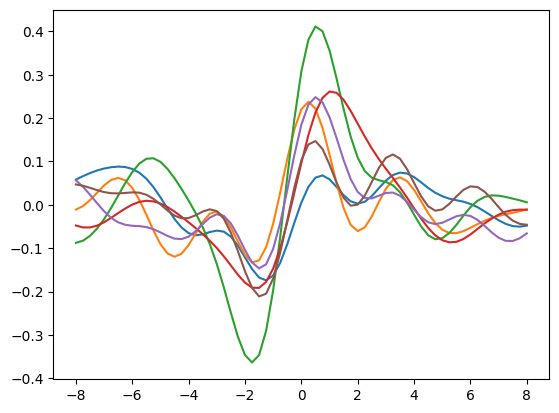

In [10]:
plt.plot(lags, col_rh_lag_kw_basin_era5)

# Load TC genesis composite with KW phase

In [5]:
data = np.load(file_dir_ace2_100yr + 'TCgenesis_lag_kwcrest_TCano_daily.npz')
bin_center = data['bin_center']
TC_obs_ano = data['TC_obs_ano']
TC_ace2_ano = data['TC_ace2_ano']

In [18]:
print(np.shape(TC_obs_ano))

(17, 6)


# Check if there is nan data in TC and environment

In [22]:
print( np.sum(np.isnan(TC_obs_ano)) )
print( np.sum(np.isnan(TC_ace2_ano)) )
print( np.sum(np.isnan(shear_lag_kw_basin_ace2_daily)))
print( np.sum(np.isnan(col_rh_lag_kw_basin_ace2_daily)) )
print( np.sum(np.isnan(abs_vor_clip_lag_kw_basin_ace2_daily)) )
print( np.sum(np.isnan(relsst_lag_kw_basin_ace2_daily)) )

0
0
0
0
0
0


In [23]:
print( np.max(TC_obs_ano)) 
print( np.max(TC_ace2_ano))
print( np.max(shear_lag_kw_basin_ace2_daily))
print( np.max(col_rh_lag_kw_basin_ace2_daily))
print( np.max(abs_vor_clip_lag_kw_basin_ace2_daily))
print( np.max(relsst_lag_kw_basin_ace2_daily))

0.16262043689212566
0.0756781796742779
0.2584720720286819
0.3948576658855407
2.6809957418439967e-07
0.0015731084993060647


In [24]:
print( np.min(TC_obs_ano)) 
print( np.min(TC_ace2_ano))
print( np.min(shear_lag_kw_basin_ace2_daily))
print( np.min(col_rh_lag_kw_basin_ace2_daily))
print( np.min(abs_vor_clip_lag_kw_basin_ace2_daily))
print( np.min(relsst_lag_kw_basin_ace2_daily))

-0.08366879989572279
-0.05107315317238528
-0.14463093400826948
-0.3427258385125397
-2.0253224650660828e-07
-0.001362131467298516


# Load the mean state TC and environmental condition

In [6]:
# Load the mean state TC counts

# Load lag day data for ACE2 (100yr)
data = np.load(file_dir_ace2_100yr+'TC_genesis_30SN/TCgenesis_lag_kwcrest_hr_10SN_basin_summer_only_100yr.npz')
dhr_ace2_basin0_100yr = data['dhr_ace2_basin0_100yr']
dhr_ace2_basin1_100yr = data['dhr_ace2_basin1_100yr']
dhr_ace2_basin2_100yr = data['dhr_ace2_basin2_100yr']
dhr_ace2_basin3_100yr = data['dhr_ace2_basin3_100yr']
dhr_ace2_basin4_100yr = data['dhr_ace2_basin4_100yr']
dhr_ace2_basin5_100yr = data['dhr_ace2_basin5_100yr']
basin_list = data['basin_list']
nbasin     = np.size(basin_list)

# Load lag day data for obs
data            = np.load(file_dir_obs_ace2+'TCgenesis_lag_kwcrest_hr_10SN_era5_basin_summer_only.npz')
dhr_era5_basin0 = data['dhr_basin0']
dhr_era5_basin1 = data['dhr_basin1']
dhr_era5_basin2 = data['dhr_basin2']
dhr_era5_basin3 = data['dhr_basin3']
dhr_era5_basin4 = data['dhr_basin4']
dhr_era5_basin5 = data['dhr_basin5']

# Count number of TCs per year
ntc_yr_ace2 = (np.size(dhr_ace2_basin0_100yr) + np.size(dhr_ace2_basin1_100yr) + np.size(dhr_ace2_basin2_100yr) + \
    np.size(dhr_ace2_basin3_100yr) + np.size(dhr_ace2_basin4_100yr) + np.size(dhr_ace2_basin5_100yr))/100

ntc_yr_obs = (np.size(dhr_era5_basin0) + np.size(dhr_era5_basin1) + np.size(dhr_era5_basin2) + \
    np.size(dhr_era5_basin3) + np.size(dhr_era5_basin4) + np.size(dhr_era5_basin5))/10


In [12]:
print(ntc_yr_ace2)
print(ntc_yr_obs)

39.11
53.6


In [7]:
# Environmental condition
filename                 = 'TCGI_ACE2_2001_2010_2.5deg_6h.nc'
ds                       = xr.open_dataset(file_dir_ace2 + filename)
absvor_clipped_ace2_mean = ds['absvor_clipped'].mean(dim='time', skipna=True).mean(dim='lat', skipna=True).mean(dim='lon', skipna=True).values
shear_ace2_mean          = ds['shear'].mean(dim='time', skipna=True).mean(dim='lat', skipna=True).mean(dim='lon', skipna=True).values
col_rh_ace2_mean         = ds['col_rh'].mean(dim='time', skipna=True).mean(dim='lat', skipna=True).mean(dim='lon', skipna=True).values
relsst_ace2_mean         = ds['relsst'].mean(dim='time', skipna=True).mean(dim='lat', skipna=True).mean(dim='lon', skipna=True).values

filename                 = 'TCGI_ERA5_2001_2010_2.5deg_6h.nc'
ds                       = xr.open_dataset(file_dir_obs_tcgi + filename)
absvor_clipped_obs_mean = ds['absvor_clipped'].mean(dim='time', skipna=True).mean(dim='lat', skipna=True).mean(dim='lon', skipna=True).values
shear_obs_mean          = ds['shear'].mean(dim='time', skipna=True).mean(dim='lat', skipna=True).mean(dim='lon', skipna=True).values
col_rh_obs_mean         = ds['col_rh'].mean(dim='time', skipna=True).mean(dim='lat', skipna=True).mean(dim='lon', skipna=True).values
relsst_obs_mean         = ds['relsst'].mean(dim='time', skipna=True).mean(dim='lat', skipna=True).mean(dim='lon', skipna=True).values

In [34]:
print(absvor_clipped_ace2_mean)
print(shear_ace2_mean)
print(col_rh_ace2_mean)
print(relsst_ace2_mean)
#
print(absvor_clipped_obs_mean)
print(shear_obs_mean)
print(col_rh_obs_mean)
print(relsst_obs_mean)

2.793538170815894e-05
17.68781293684654
54.14240646671798
-1.258302876727203
2.8119316809971042e-05
22.17778517347372
53.3228865607493
-1.2583846491919815


# Add the mean state back so that Poisson regression can work

In [8]:
# TC
TC_obs = TC_obs_ano + ntc_yr_obs
TC_ace2 = TC_ace2_ano + ntc_yr_ace2

In [9]:
# Env condition
shear_ace2        = shear_lag_kw_basin_ace2_daily + shear_ace2_mean
col_rh_ace2       = col_rh_lag_kw_basin_ace2_daily + col_rh_ace2_mean
abs_vor_clip_ace2 = abs_vor_clip_lag_kw_basin_ace2_daily + absvor_clipped_ace2_mean
relsst_ace2       = relsst_lag_kw_basin_ace2_daily + relsst_ace2_mean
#
shear_obs        = shear_lag_kw_basin_obs_daily + shear_obs_mean
col_rh_obs       = col_rh_lag_kw_basin_obs_daily + col_rh_obs_mean
abs_vor_clip_obs = abs_vor_clip_lag_kw_basin_obs_daily + absvor_clipped_obs_mean
relsst_obs       = relsst_lag_kw_basin_obs_daily + relsst_obs_mean

In [29]:
print(abs_vor_clip_obs)

[[2.81338612e-05 2.80759061e-05 2.80919580e-05 2.81105484e-05
  2.81245089e-05 2.81109852e-05]
 [2.81500246e-05 2.80817826e-05 2.81022405e-05 2.81170295e-05
  2.80975759e-05 2.81001404e-05]
 [2.81384051e-05 2.80947399e-05 2.81319120e-05 2.81306637e-05
  2.80915153e-05 2.80943219e-05]
 [2.81067717e-05 2.80755008e-05 2.81511656e-05 2.81324710e-05
  2.80993480e-05 2.80937961e-05]
 [2.81068667e-05 2.80865856e-05 2.81255412e-05 2.81059240e-05
  2.81015066e-05 2.80919897e-05]
 [2.81319721e-05 2.81173535e-05 2.80841993e-05 2.80804174e-05
  2.81183334e-05 2.80962028e-05]
 [2.81322557e-05 2.81102492e-05 2.80358472e-05 2.80627952e-05
  2.81017225e-05 2.80807864e-05]
 [2.81079494e-05 2.81608910e-05 2.80388363e-05 2.80802009e-05
  2.80922426e-05 2.80989957e-05]
 [2.81216224e-05 2.82436708e-05 2.81880607e-05 2.81508608e-05
  2.81629666e-05 2.81903592e-05]
 [2.81299605e-05 2.82227308e-05 2.82775375e-05 2.81887438e-05
  2.81911285e-05 2.82201873e-05]
 [2.80933499e-05 2.81534055e-05 2.81791816e-05 2.8

In [33]:
print(col_rh_obs)

[[53.38107388 53.31199663 53.235356   53.2753319  53.37946942 53.36994191]
 [53.40660663 53.36763037 53.28991965 53.282776   53.30818205 53.35231274]
 [53.40560909 53.36207219 53.39843076 53.32345676 53.27467459 53.35172208]
 [53.34022113 53.2325239  53.42197969 53.32600191 53.25946046 53.32397191]
 [53.25768609 53.23017247 53.33278189 53.28266193 53.24971782 53.29252889]
 [53.26353269 53.30755511 53.18649312 53.22342363 53.30135296 53.30844411]
 [53.20183533 53.20765911 52.97673231 53.14364518 53.21872856 53.16987986]
 [53.16007636 53.27970053 53.126341   53.17603771 53.22157174 53.15308098]
 [53.3281555  53.5430821  53.63040276 53.41924551 53.50742915 53.42553508]
 [53.38180899 53.43894213 53.67871232 53.58412192 53.5249157  53.41578836]
 [53.32574672 53.26245453 53.4316659  53.51005984 53.35263772 53.32334555]
 [53.37886356 53.35993231 53.37581281 53.40608002 53.35036752 53.43134974]
 [53.38687474 53.35748392 53.30037317 53.31501082 53.31174036 53.37347361]
 [53.34279847 53.26564602

# Start calibration

In [34]:
# Calculate ACE2
import pandas as pd
data = {
    'TC': np.ndarray.flatten(TC_ace2),  # Dependent variable (count data)
    'shear': np.ndarray.flatten(shear_ace2),     # Independent variable 1
    'colrh': np.ndarray.flatten(col_rh_ace2),      # Independent variable 2
    'relsst': np.ndarray.flatten(relsst_ace2),
    'absvor': np.ndarray.flatten(abs_vor_clip_ace2)*10**5,
}
df = pd.DataFrame(data)

# Dependent variable (count data)
y = df['TC']

# Independent variables (predictors)
X = df[['shear', 'colrh','relsst','absvor']]
X = sm.add_constant(X)  # Add an intercept term

# Fit the Poisson regression model
model = sm.GLM(y, X, family=sm.families.Poisson())
results = model.fit()

# Extract the coefficients
coefficients_ace2 = results.params
print("Coefficients:")
print(coefficients_ace2)

# Summary of the model
print("\nModel Summary:")
print(results.summary())

# Write down the coefficients
TCGI_ace2 = np.exp(coefficients_ace2['const']+ coefficients_ace2['shear']*shear_ace2 + coefficients_ace2['colrh']*col_rh_ace2 + \
    coefficients_ace2['relsst']*relsst_ace2 + coefficients_ace2['absvor']*abs_vor_clip_ace2*10**(-5))
TCGI_ace2_ano = TCGI_ace2 - np.mean(TCGI_ace2)

# Predict the expected counts
TC_ace2_pred = results.predict(X)

Coefficients:
const     3.341700
shear    -0.002057
colrh    -0.000013
relsst   -0.203950
absvor    0.037632
dtype: float64

Model Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                     TC   No. Observations:                  102
Model:                            GLM   Df Residuals:                       97
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -280.93
Date:                Fri, 19 Sep 2025   Deviance:                   0.00070023
Time:                        17:11:10   Pearson chi2:                 0.000700
No. Iterations:                     2   Pseudo R-squ. (CS):          4.128e-06
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025    

In [61]:
print(np.shape(TC_obs))
print(np.shape(shear_obs))

(17, 6)
(17, 6)


In [39]:
print(relsst_obs)

[[-1.25865792 -1.25779935 -1.25448573 -1.25543761 -1.25847357 -1.25627039]
 [-1.25801486 -1.25627946 -1.25541256 -1.25553269 -1.2568704  -1.25582051]
 [-1.25817341 -1.25491799 -1.25651456 -1.25590563 -1.25592253 -1.25636662]
 [-1.2592494  -1.25596986 -1.25753543 -1.25670491 -1.25611856 -1.25746765]
 [-1.25955917 -1.25731384 -1.25900512 -1.25694668 -1.25612785 -1.25844914]
 [-1.25966237 -1.25805889 -1.26121676 -1.25792032 -1.25728057 -1.26013924]
 [-1.25927464 -1.25856535 -1.26200792 -1.2589093  -1.25741188 -1.26146711]
 [-1.25806969 -1.25922808 -1.26264038 -1.25981832 -1.25726249 -1.26272386]
 [-1.25922276 -1.26134066 -1.26436209 -1.26182915 -1.26042033 -1.26415272]
 [-1.26079903 -1.26116375 -1.26262767 -1.26247471 -1.26146336 -1.26254875]
 [-1.26077862 -1.25796504 -1.25919605 -1.26114926 -1.2600941  -1.2594619 ]
 [-1.25993476 -1.25731463 -1.25774258 -1.25936853 -1.26042072 -1.25856957]
 [-1.25854187 -1.25813131 -1.25671731 -1.25756182 -1.25949687 -1.25776838]
 [-1.25754563 -1.25812537

In [38]:
# Calculate OBS TCGI
import pandas as pd
data = {
    'TC': np.ndarray.flatten(TC_obs),  # Dependent variable (count data)
    'shear': np.ndarray.flatten(shear_obs),     # Independent variable 1
    'colrh': np.ndarray.flatten(col_rh_obs),      # Independent variable 2
    'relsst': np.ndarray.flatten(relsst_obs),
    'absvor': np.ndarray.flatten(abs_vor_clip_obs)*10**5,
}
df = pd.DataFrame(data)

# Dependent variable (count data)
y = np.log(df['TC'])

# Independent variables (predictors)
X = df[['shear', 'colrh','relsst','absvor']]
X = sm.add_constant(X)  # Add an intercept term

# Fit the Poisson regression model
model = sm.GLM(y, X, family=sm.families.Poisson())
results = model.fit()

# Extract the coefficients
coefficients_obs = results.params
print("Coefficients:")
print(coefficients_obs)

# Summary of the model
print("\nModel Summary:")
print(results.summary())

# Write down the coefficients
TCGI_obs = np.exp(coefficients_obs['const']+ coefficients_obs['shear']*shear_obs + coefficients_obs['colrh']*col_rh_obs + \
    coefficients_obs['relsst']*relsst_obs + coefficients_obs['absvor']*abs_vor_clip_obs*10**(-5))
TCGI_obs_ano = TCGI_obs - np.mean(TCGI_obs)

# Predict the expected counts
TC_obs_pred = results.predict(X)

Coefficients:
const     3.900633
shear    -0.002214
colrh     0.001509
relsst   -0.085051
absvor   -0.020442
dtype: float64

Model Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                     TC   No. Observations:                  102
Model:                            GLM   Df Residuals:                       97
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -296.95
Date:                Fri, 19 Sep 2025   Deviance:                    0.0023791
Time:                        17:20:30   Pearson chi2:                  0.00238
No. Iterations:                     2   Pseudo R-squ. (CS):          4.980e-06
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025    

In [43]:
# Check what is wrong for Poisson regression (NOT SUCCESSFUL! START HERE!!! I THINK WE CAN USE 6-HOUR TC data)

# 1) dispersion = deviance / df_resid
dispersion = results.deviance / results.df_resid
print("Dispersion:", dispersion)

# 2) VIF for multicollinearity (exclude intercept column when computing VIF)
X_noint = X[:,1:]
vifs = [variance_inflation_factor(X_noint, i) for i in range(X_noint.shape[1])]
print("VIFs:", vifs)

# 3) Robust (sandwich) SEs to see if heteroskedasticity / misspecification affects SEs
robust = results.get_robustcov_results(cov_type='HC3')
print(robust.summary())

Dispersion: 2.452731799794855e-05


InvalidIndexError: (slice(None, None, None), slice(1, None, None))

In [45]:
print(np.shape(X[:,1:]))

InvalidIndexError: (slice(None, None, None), slice(1, None, None))

In [40]:
print(TC_pred)

0      39.109935
1      39.112586
2      39.117170
3      39.116552
4      39.112556
         ...    
97     39.108245
98     39.106757
99     39.108396
100    39.109945
101    39.095874
Length: 102, dtype: float64


# Plot TC genesis and TCGI anomaly in terms of KW phase

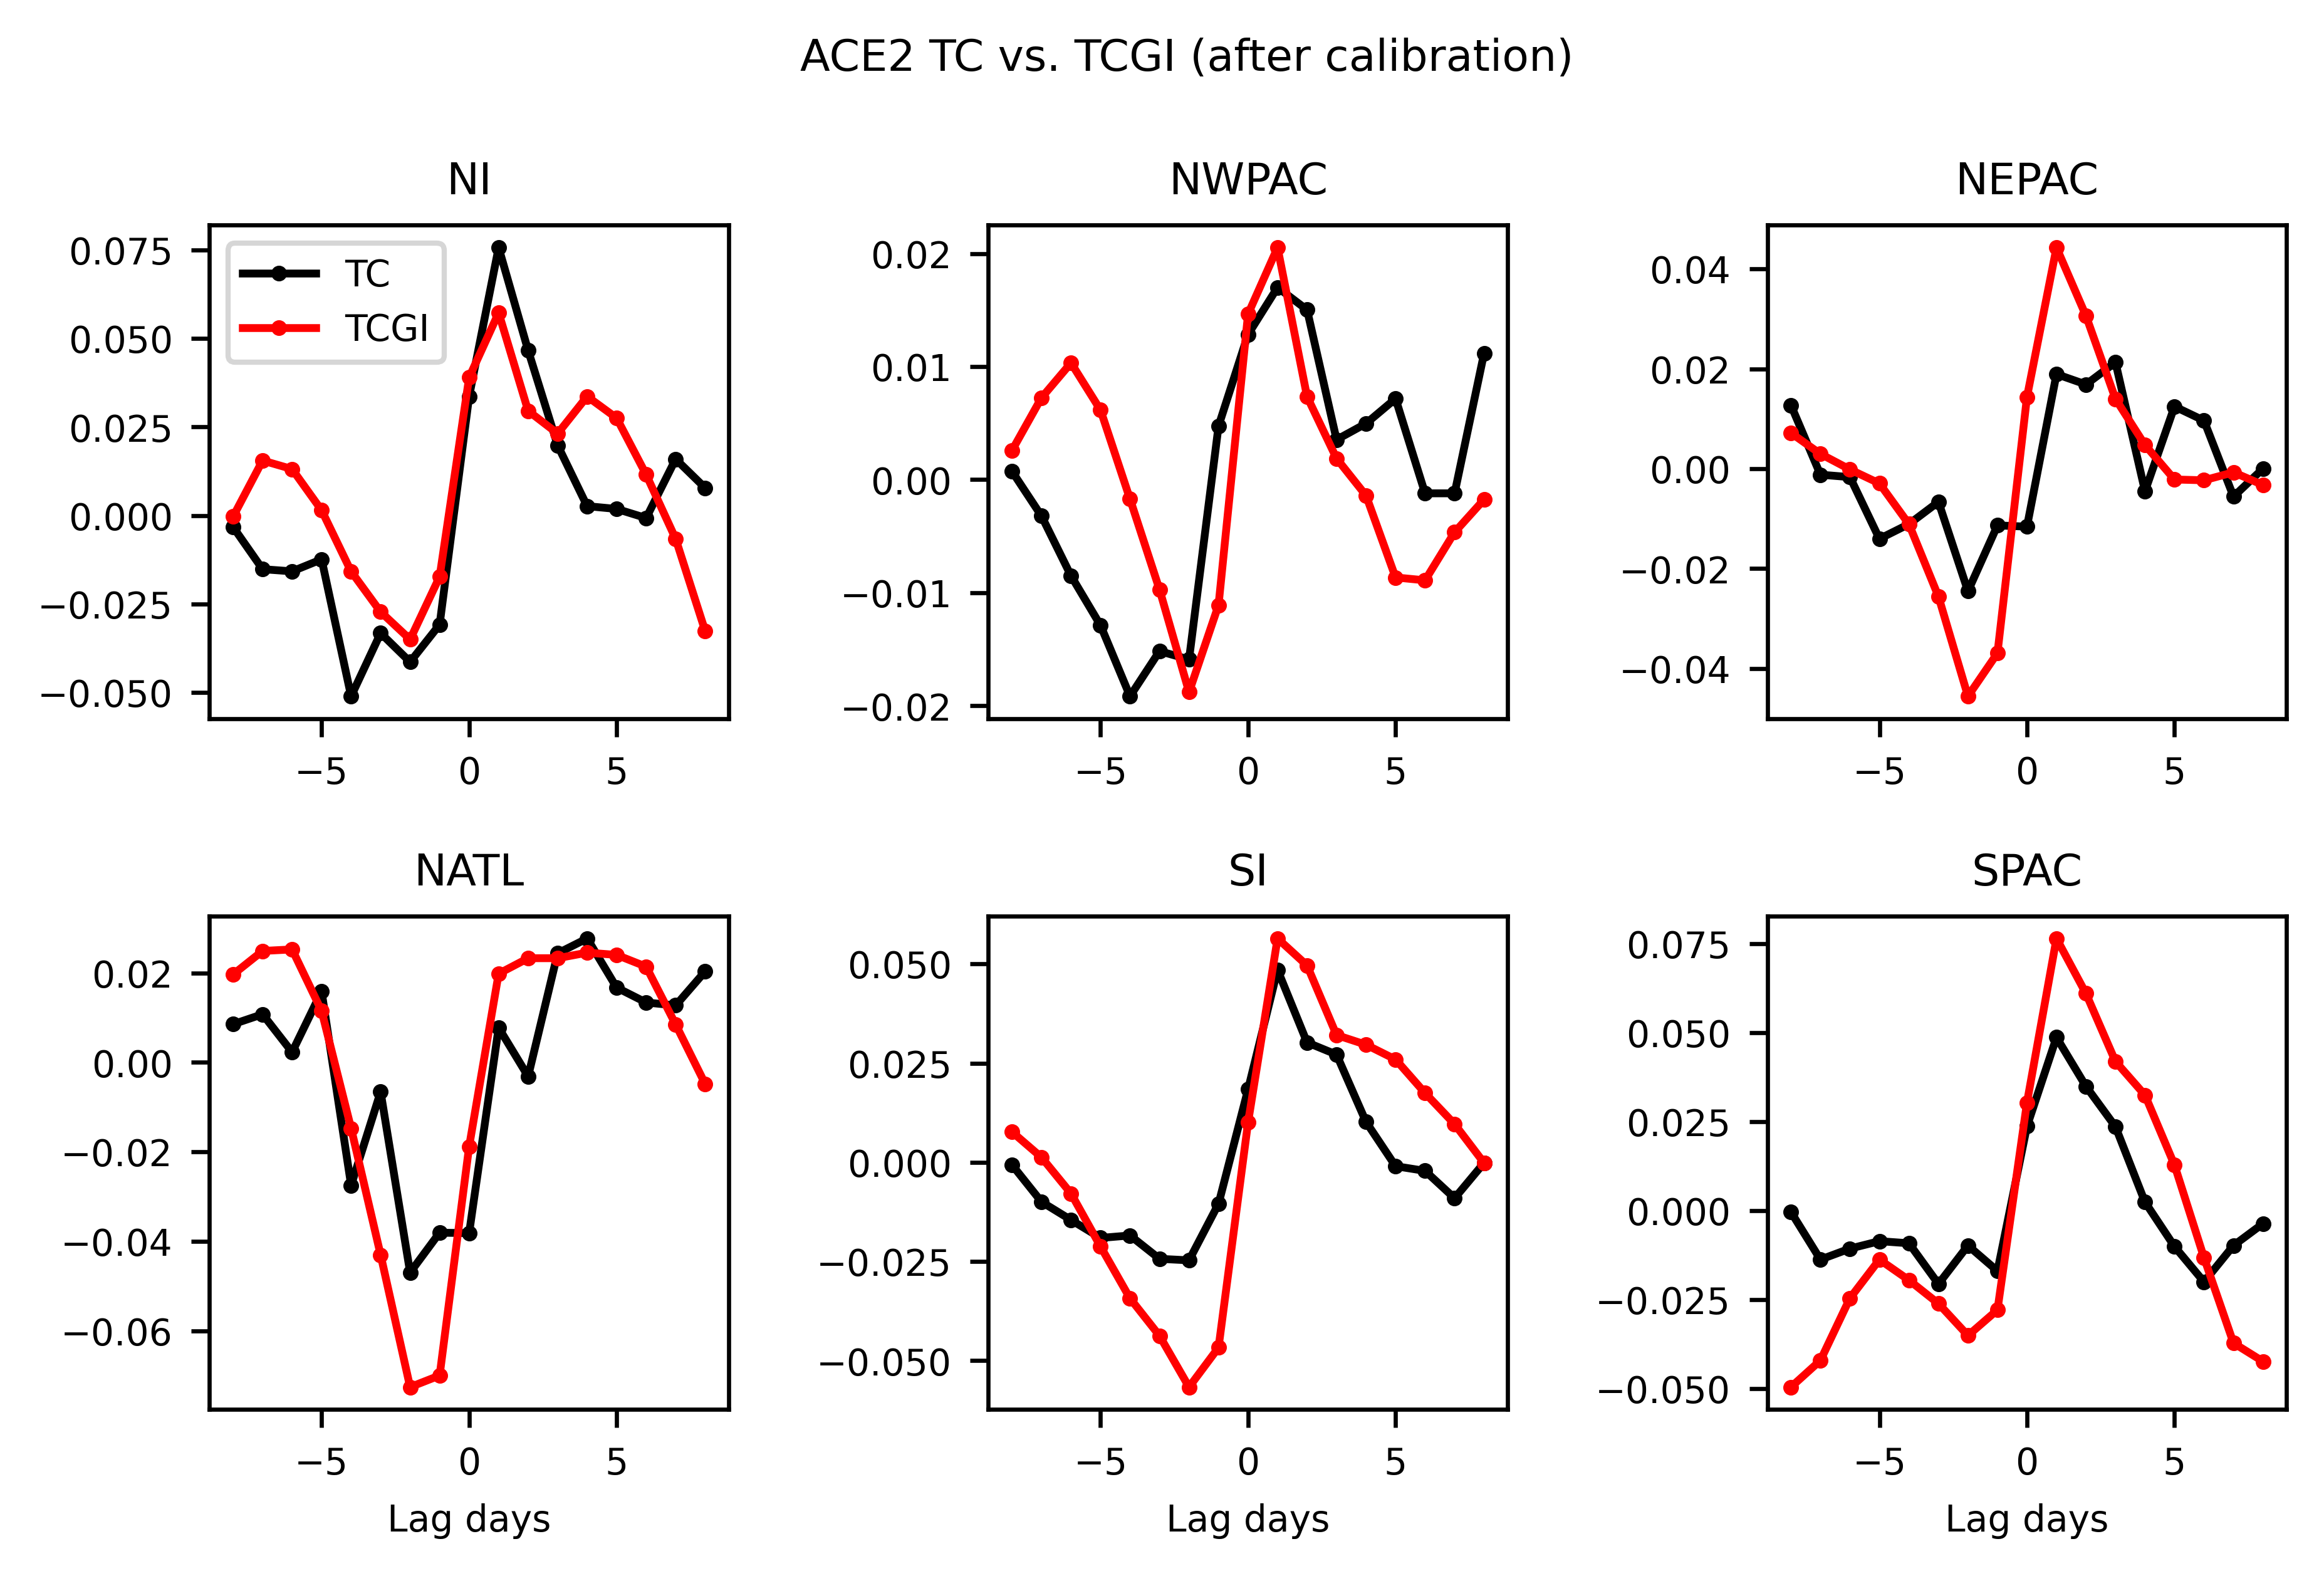

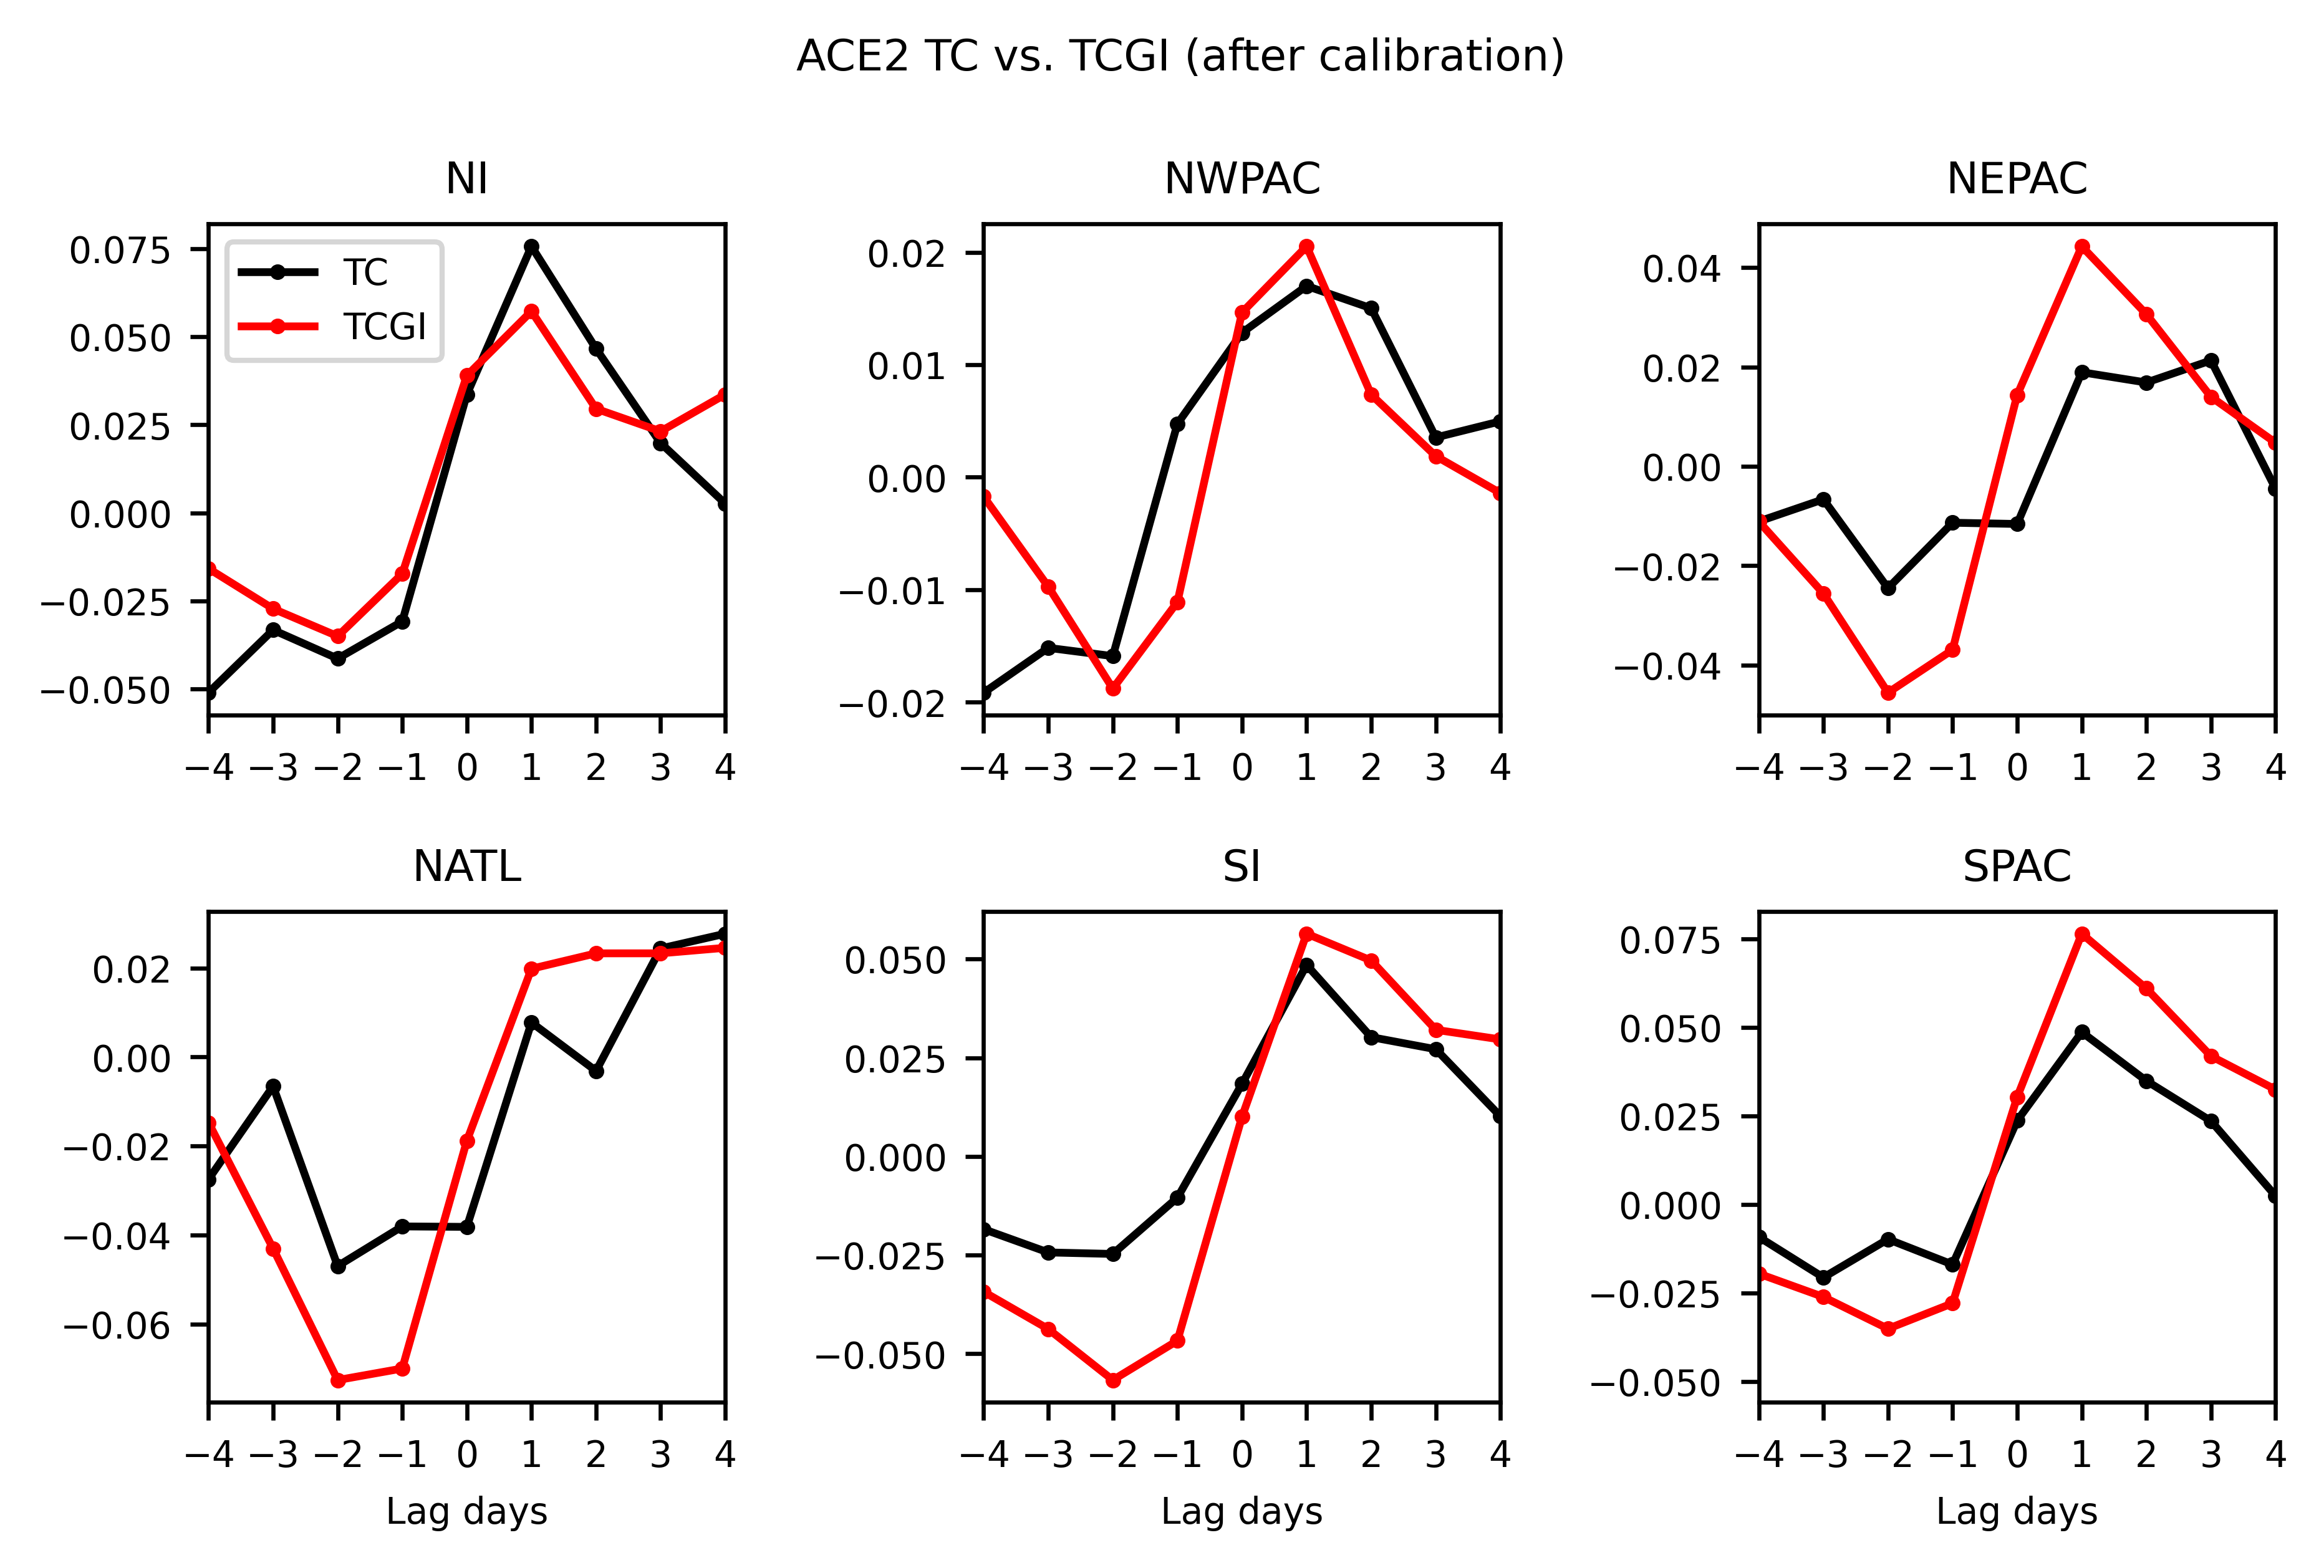

In [77]:
for iplt in range(0, 2):
    c_ace2 = np.array([5,1,1,3,3,3])
    fig, axes = plt.subplots(2,3,figsize=(6.5, 5),dpi=600)
    font = 7
    plt.rcParams.update({'font.size': font})
    plt.subplots_adjust(left=0.1,right=0.95,top=0.88,bottom=0.25, wspace=0.5, hspace=0.4)
    for ibasin in range(0, nbasin):
        plt.subplot(2, 3, ibasin+1)
        plt.plot(bin_center, TC_ace2_ano[:, ibasin], 'k-o', label='Obs', markersize=2)
        plt.plot(bin_center, TCGI_ace2_ano[:,ibasin]*c_ace2[ibasin], 'r-o', label='ACE2', markersize=2)
        plt.title(basin_list[ibasin])
        if ibasin == 0:
            plt.legend(['TC','TCGI'])

        if ibasin > 2:
            plt.xlabel('Lag days')

        if iplt == 1:
            plt.xlim([-4,4])
            plt.xticks(np.arange(-4, 5))
    plt.suptitle('ACE2 TC vs. TCGI (after calibration)')
    plt.show()

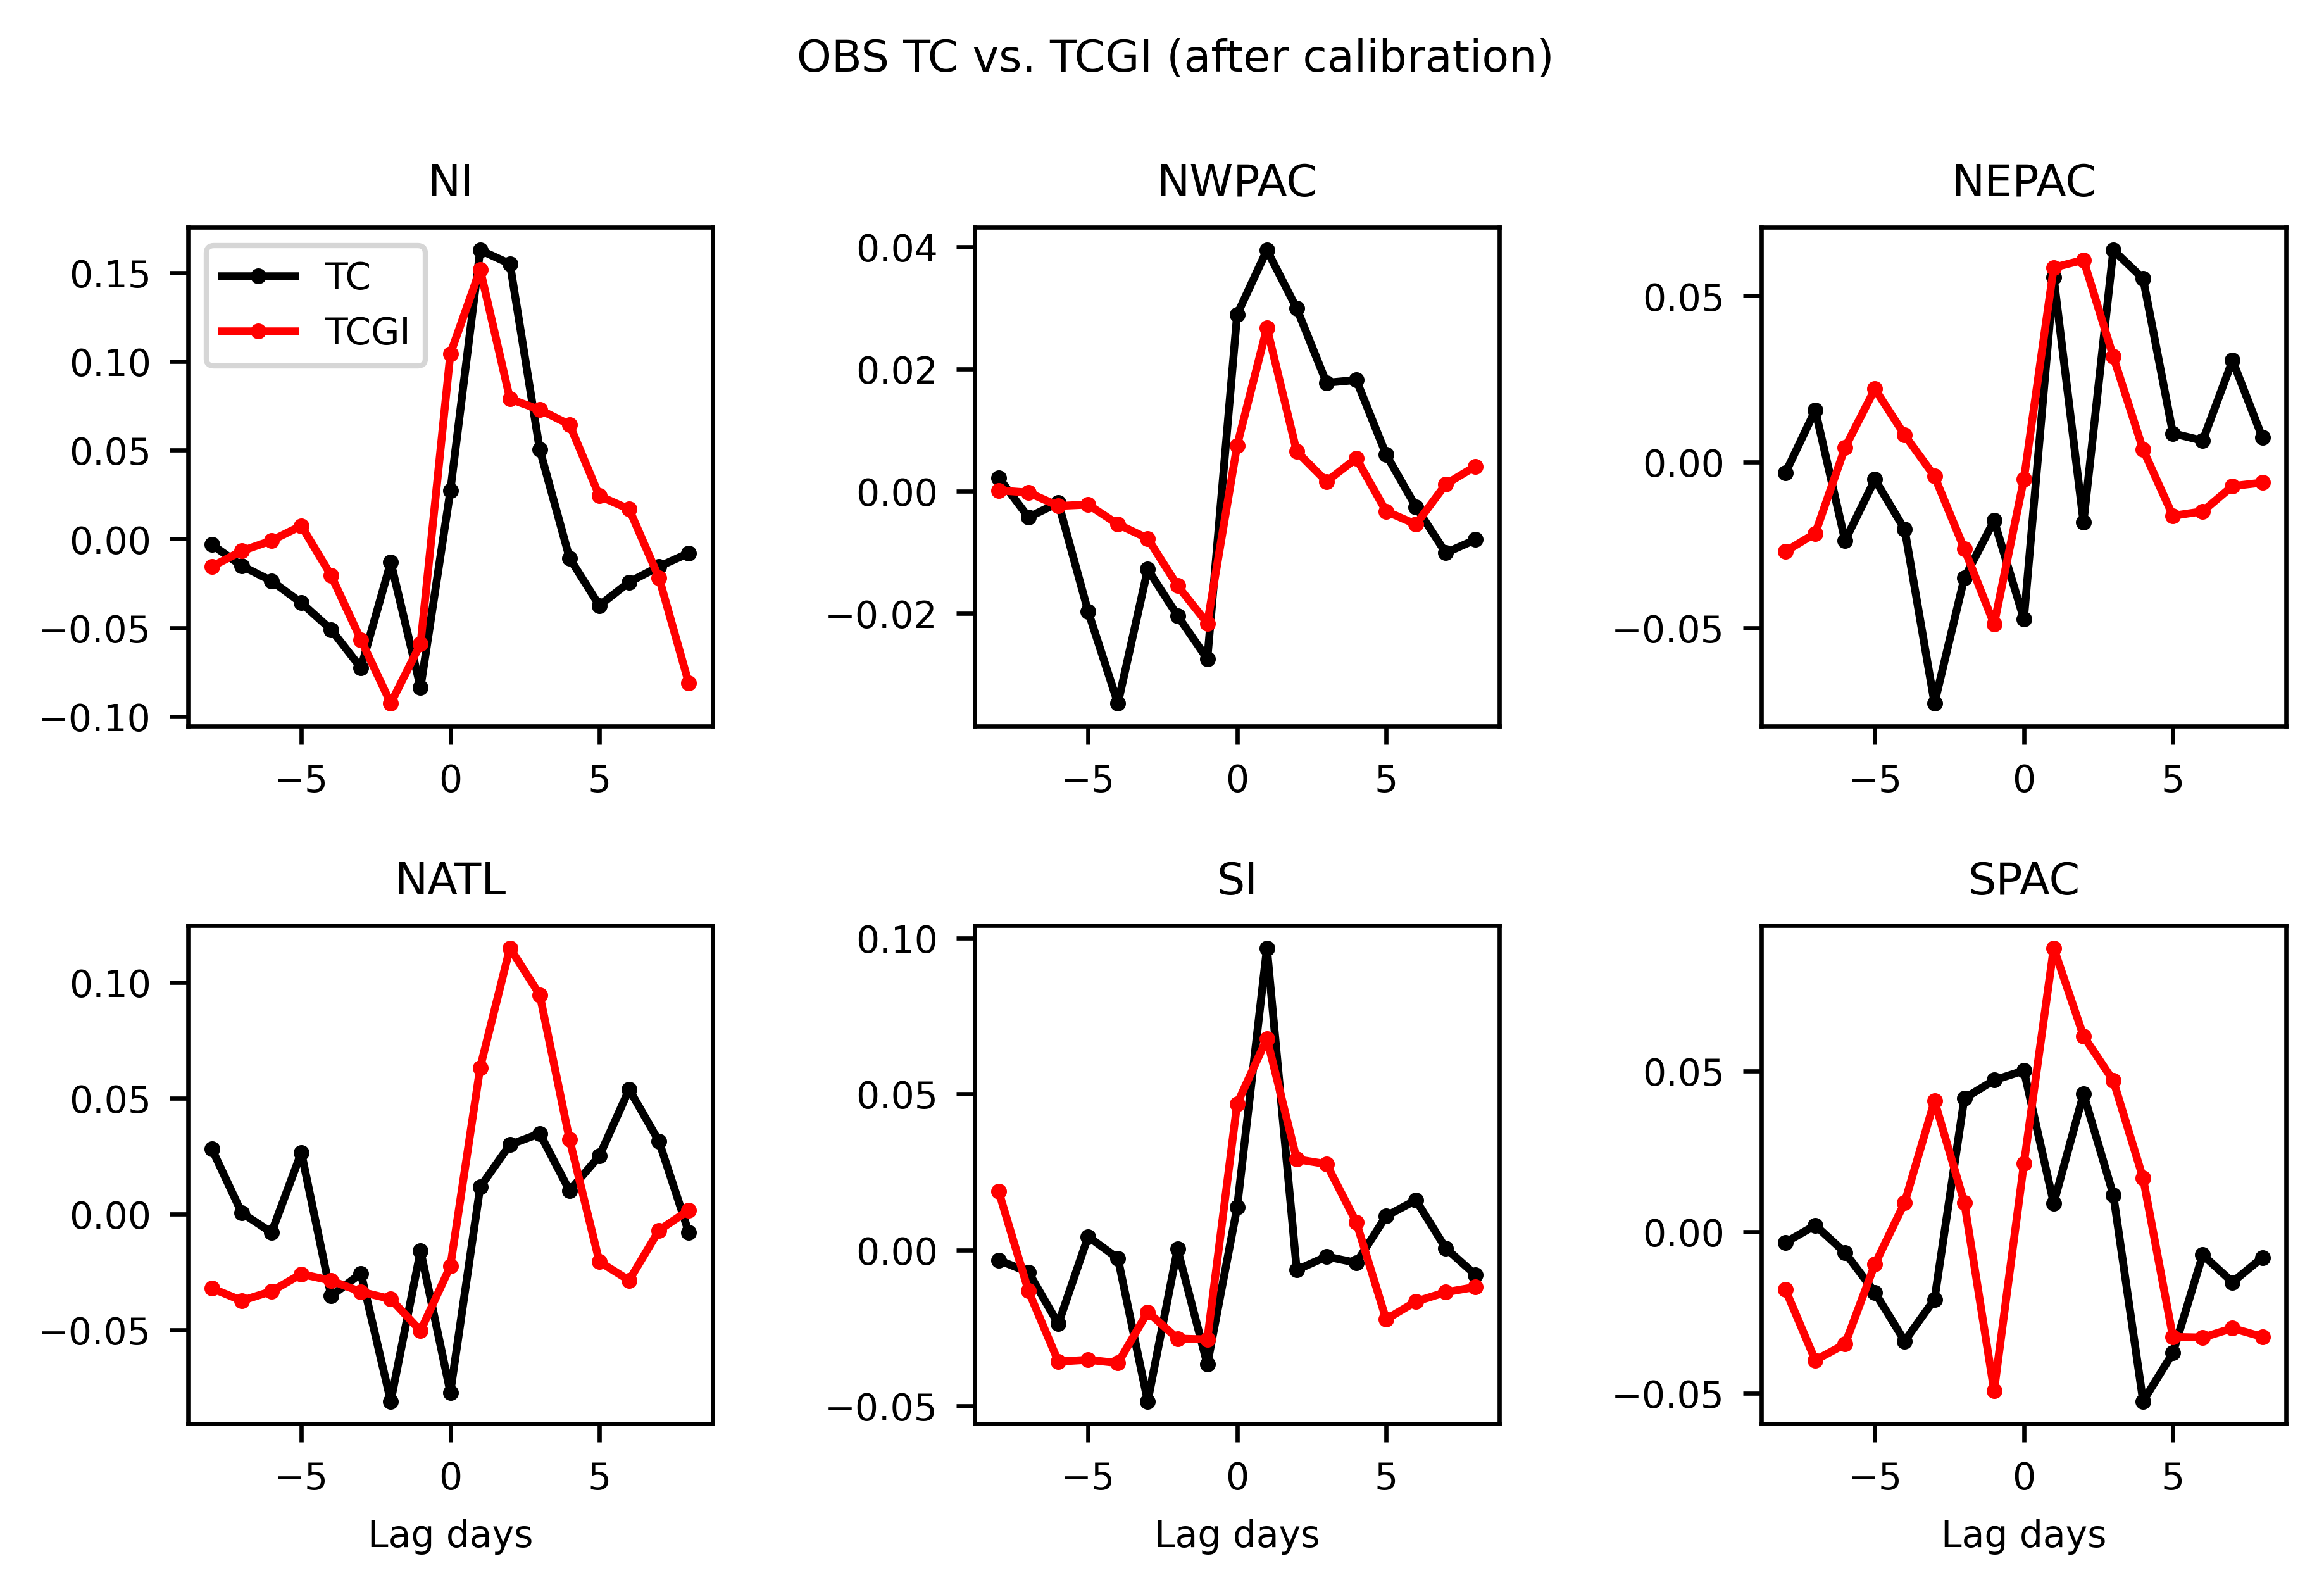

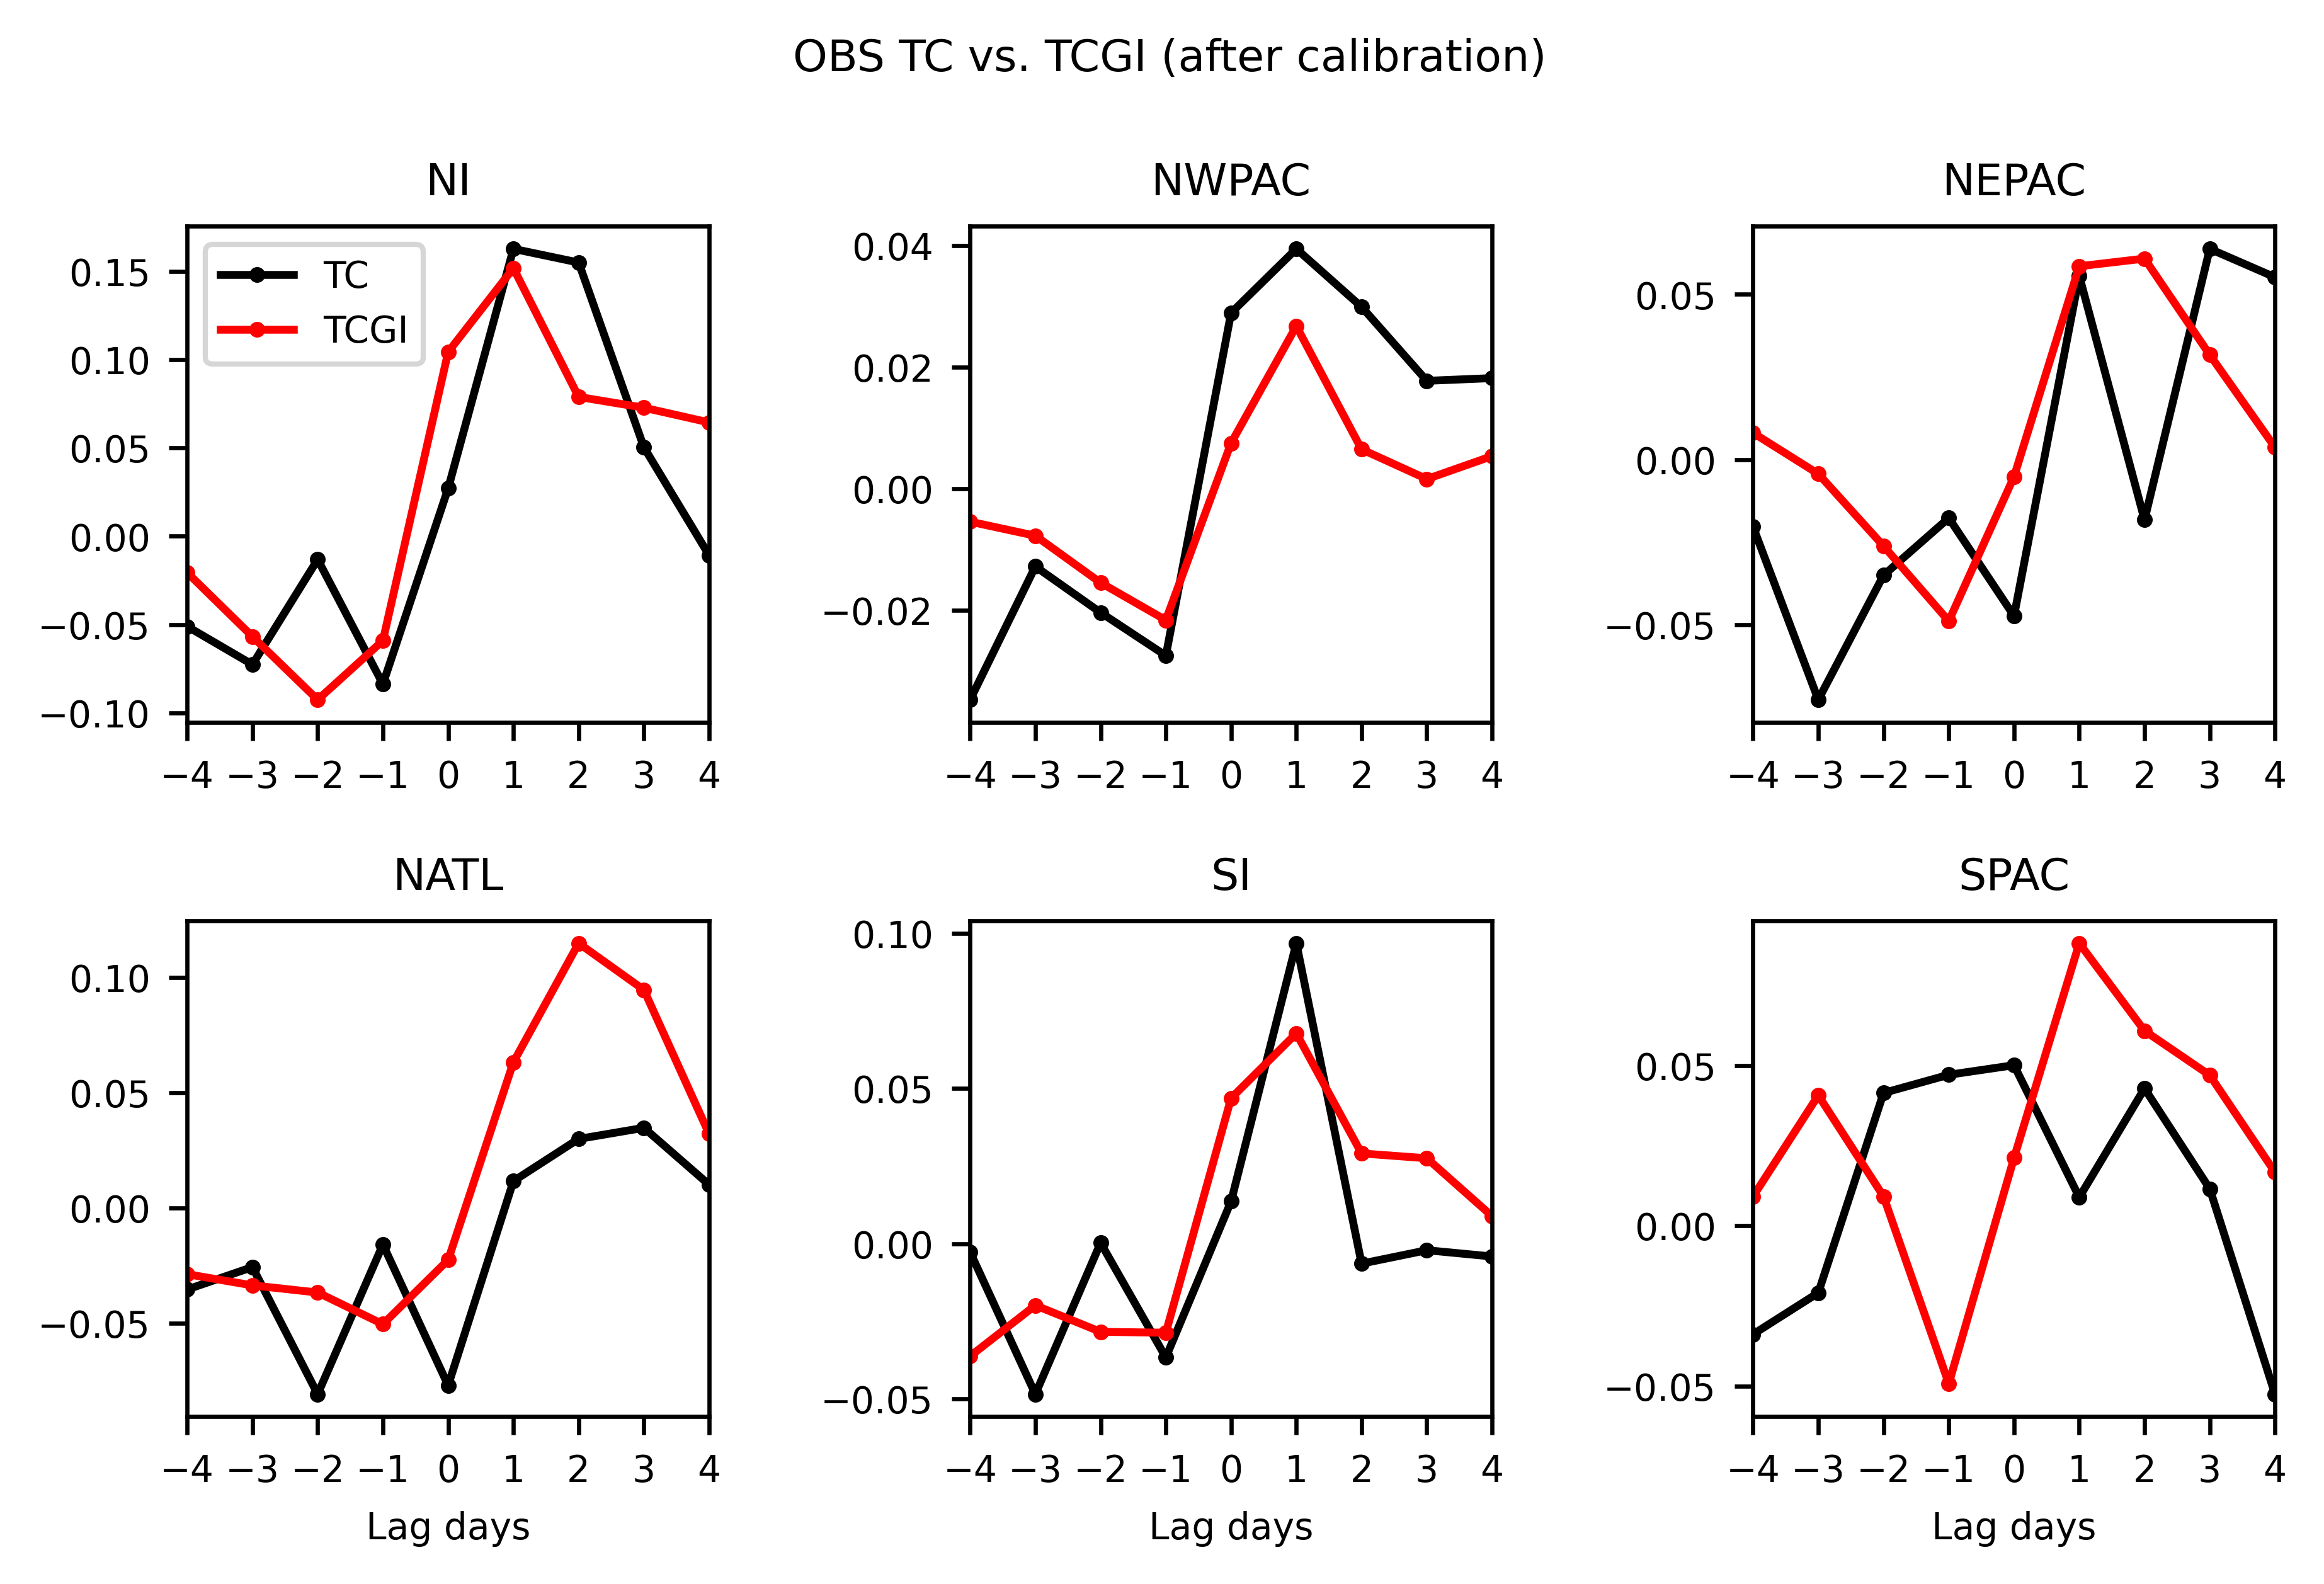

In [82]:
for iplt in range(0, 2):
    c_obs = np.array([5,1,1,3,3,3])
    fig, axes = plt.subplots(2,3,figsize=(6.5, 5),dpi=600)
    font = 7
    plt.rcParams.update({'font.size': font})
    plt.subplots_adjust(left=0.1,right=0.95,top=0.88,bottom=0.25, wspace=0.5, hspace=0.4)
    for ibasin in range(0, nbasin):
        plt.subplot(2, 3, ibasin+1)
        plt.plot(bin_center, TC_obs_ano[:, ibasin], 'k-o', markersize=2)
        plt.plot(bin_center, TCGI_obs_ano[:,ibasin]*c_obs[ibasin], 'r-o', markersize=2)
        plt.title(basin_list[ibasin])
        if ibasin == 0:
            plt.legend(['TC','TCGI'])

        if ibasin > 2:
            plt.xlabel('Lag days')

        if iplt == 1:
            plt.xlim([-4,4])
            plt.xticks(np.arange(-4, 5))
    plt.suptitle('OBS TC vs. TCGI (after calibration)')
    plt.show()

# Calculate TCGI with only 1 variable varying 

In [24]:
TCGI_shear_obs = np.exp(coefficients_obs['const']+ coefficients_obs['shear']*shear_obs + coefficients_obs['colrh']*np.mean(col_rh_obs) + \
    coefficients_obs['relsst']*np.mean(relsst_obs) + coefficients_obs['absvor']*np.mean(abs_vor_clip_obs) )

TCGI_colrh_obs = np.exp(coefficients_obs['const']+ coefficients_obs['shear']*np.mean(shear_obs) + coefficients_obs['colrh']*col_rh_obs + \
    coefficients_obs['relsst']*np.mean(relsst_obs) + coefficients_obs['absvor']*np.mean(abs_vor_clip_obs) )

TCGI_relsst_obs = np.exp(coefficients_obs['const']+ coefficients_obs['shear']*np.mean(shear_obs) + coefficients_obs['colrh']*np.mean(col_rh_obs) + \
    coefficients_obs['relsst']*relsst_obs + coefficients_obs['absvor']*np.mean(abs_vor_clip_obs) )

TCGI_absvor_obs = np.exp(coefficients_obs['const']+ coefficients_obs['shear']*np.mean(shear_obs) + coefficients_obs['colrh']*np.mean(col_rh_obs) + \
    coefficients_obs['relsst']*np.mean(relsst_obs) + coefficients_obs['absvor']*abs_vor_clip_obs )

TCGI_shear_obs_ano = TCGI_shear_obs - np.mean(TCGI_shear_obs)
TCGI_colrh_obs_ano = TCGI_colrh_obs - np.mean(TCGI_colrh_obs)
TCGI_relsst_obs_ano = TCGI_relsst_obs - np.mean(TCGI_relsst_obs)
TCGI_absvor_obs_ano = TCGI_absvor_obs - np.mean(TCGI_absvor_obs)

In [26]:
TCGI_shear_ace2 = np.exp(coefficients_ace2['const']+ coefficients_ace2['shear']*shear_ace2 + coefficients_ace2['colrh']*np.mean(col_rh_ace2) + \
    coefficients_ace2['relsst']*np.mean(relsst_ace2) + coefficients_ace2['absvor']*np.mean(abs_vor_clip_ace2) )

TCGI_colrh_ace2 = np.exp(coefficients_ace2['const']+ coefficients_ace2['shear']*np.mean(shear_ace2) + coefficients_ace2['colrh']*col_rh_ace2 + \
    coefficients_ace2['relsst']*np.mean(relsst_ace2) + coefficients_ace2['absvor']*np.mean(abs_vor_clip_ace2) )

TCGI_relsst_ace2 = np.exp(coefficients_ace2['const']+ coefficients_ace2['shear']*np.mean(shear_ace2) + coefficients_ace2['colrh']*np.mean(col_rh_ace2) + \
    coefficients_ace2['relsst']*relsst_ace2 + coefficients_ace2['absvor']*np.mean(abs_vor_clip_ace2) )

TCGI_absvor_ace2 = np.exp(coefficients_ace2['const']+ coefficients_ace2['shear']*np.mean(shear_ace2) + coefficients_ace2['colrh']*np.mean(col_rh_ace2) + \
    coefficients_ace2['relsst']*np.mean(relsst_ace2) + coefficients_ace2['absvor']*abs_vor_clip_ace2 )

TCGI_shear_ace2_ano = TCGI_shear_ace2 - np.mean(TCGI_shear_ace2)
TCGI_colrh_ace2_ano = TCGI_colrh_ace2 - np.mean(TCGI_colrh_ace2)
TCGI_relsst_ace2_ano = TCGI_relsst_ace2 - np.mean(TCGI_relsst_ace2)
TCGI_absvor_ace2_ano = TCGI_absvor_ace2 - np.mean(TCGI_absvor_ace2)

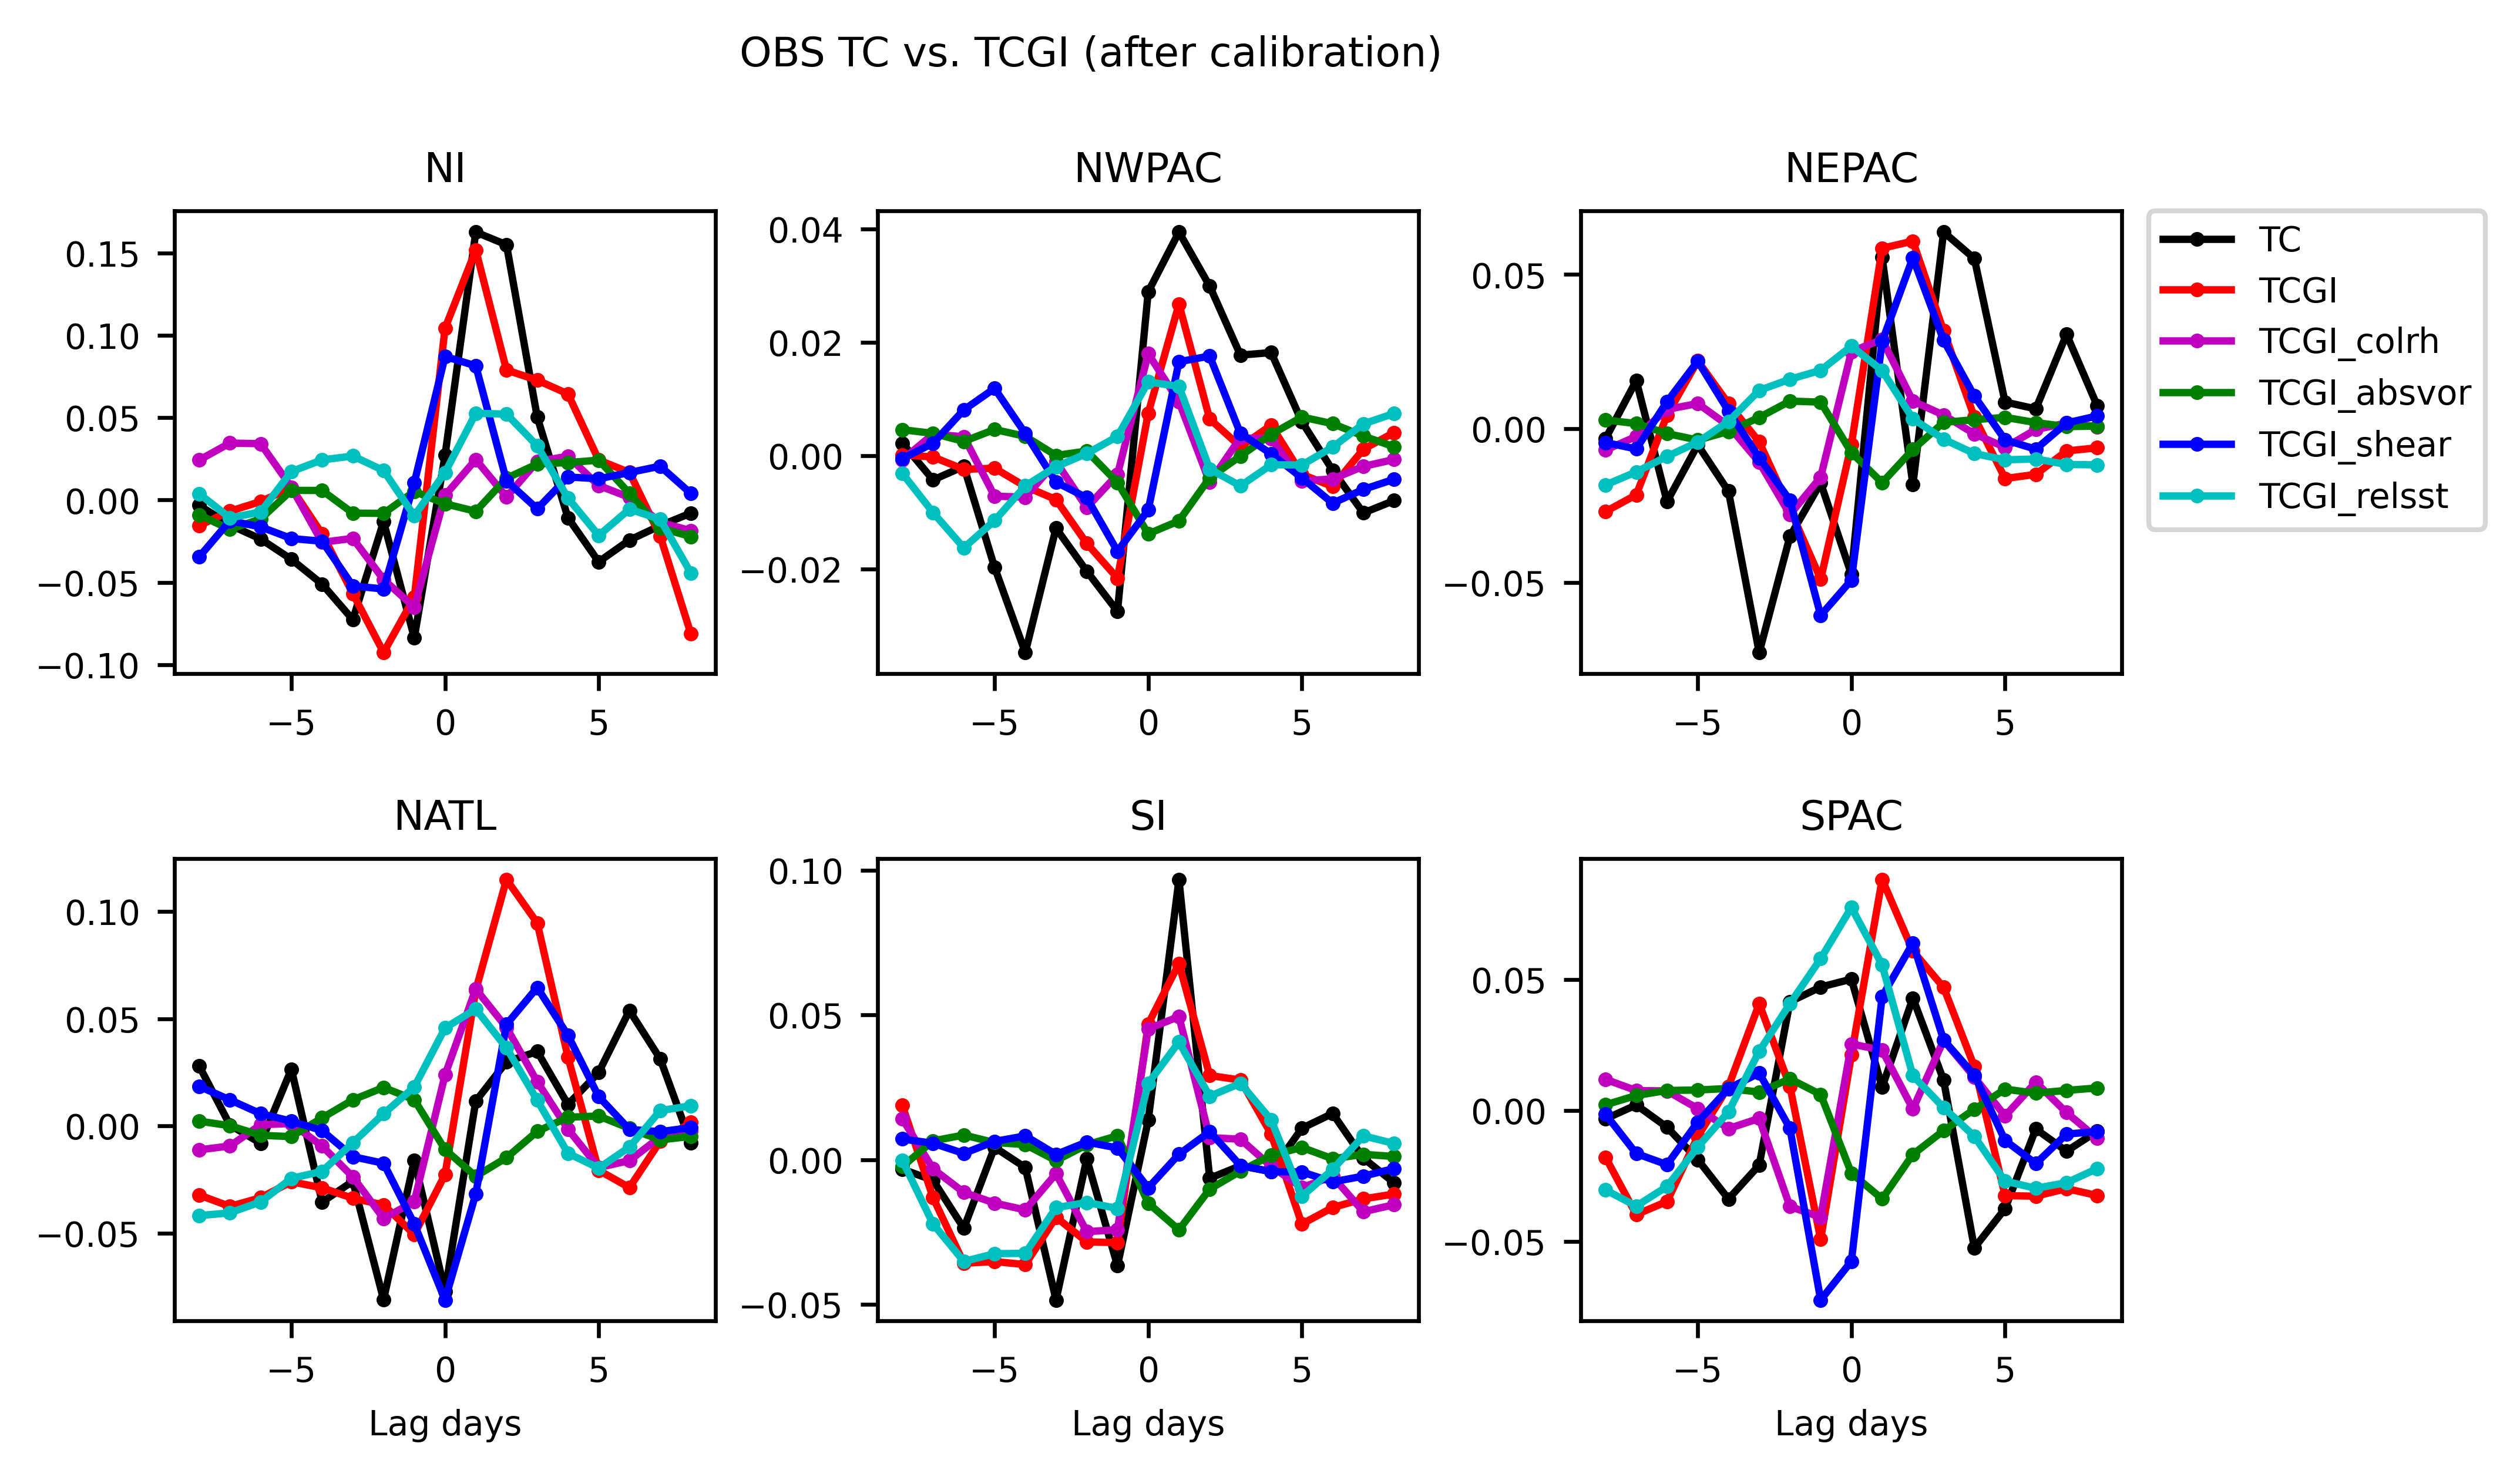

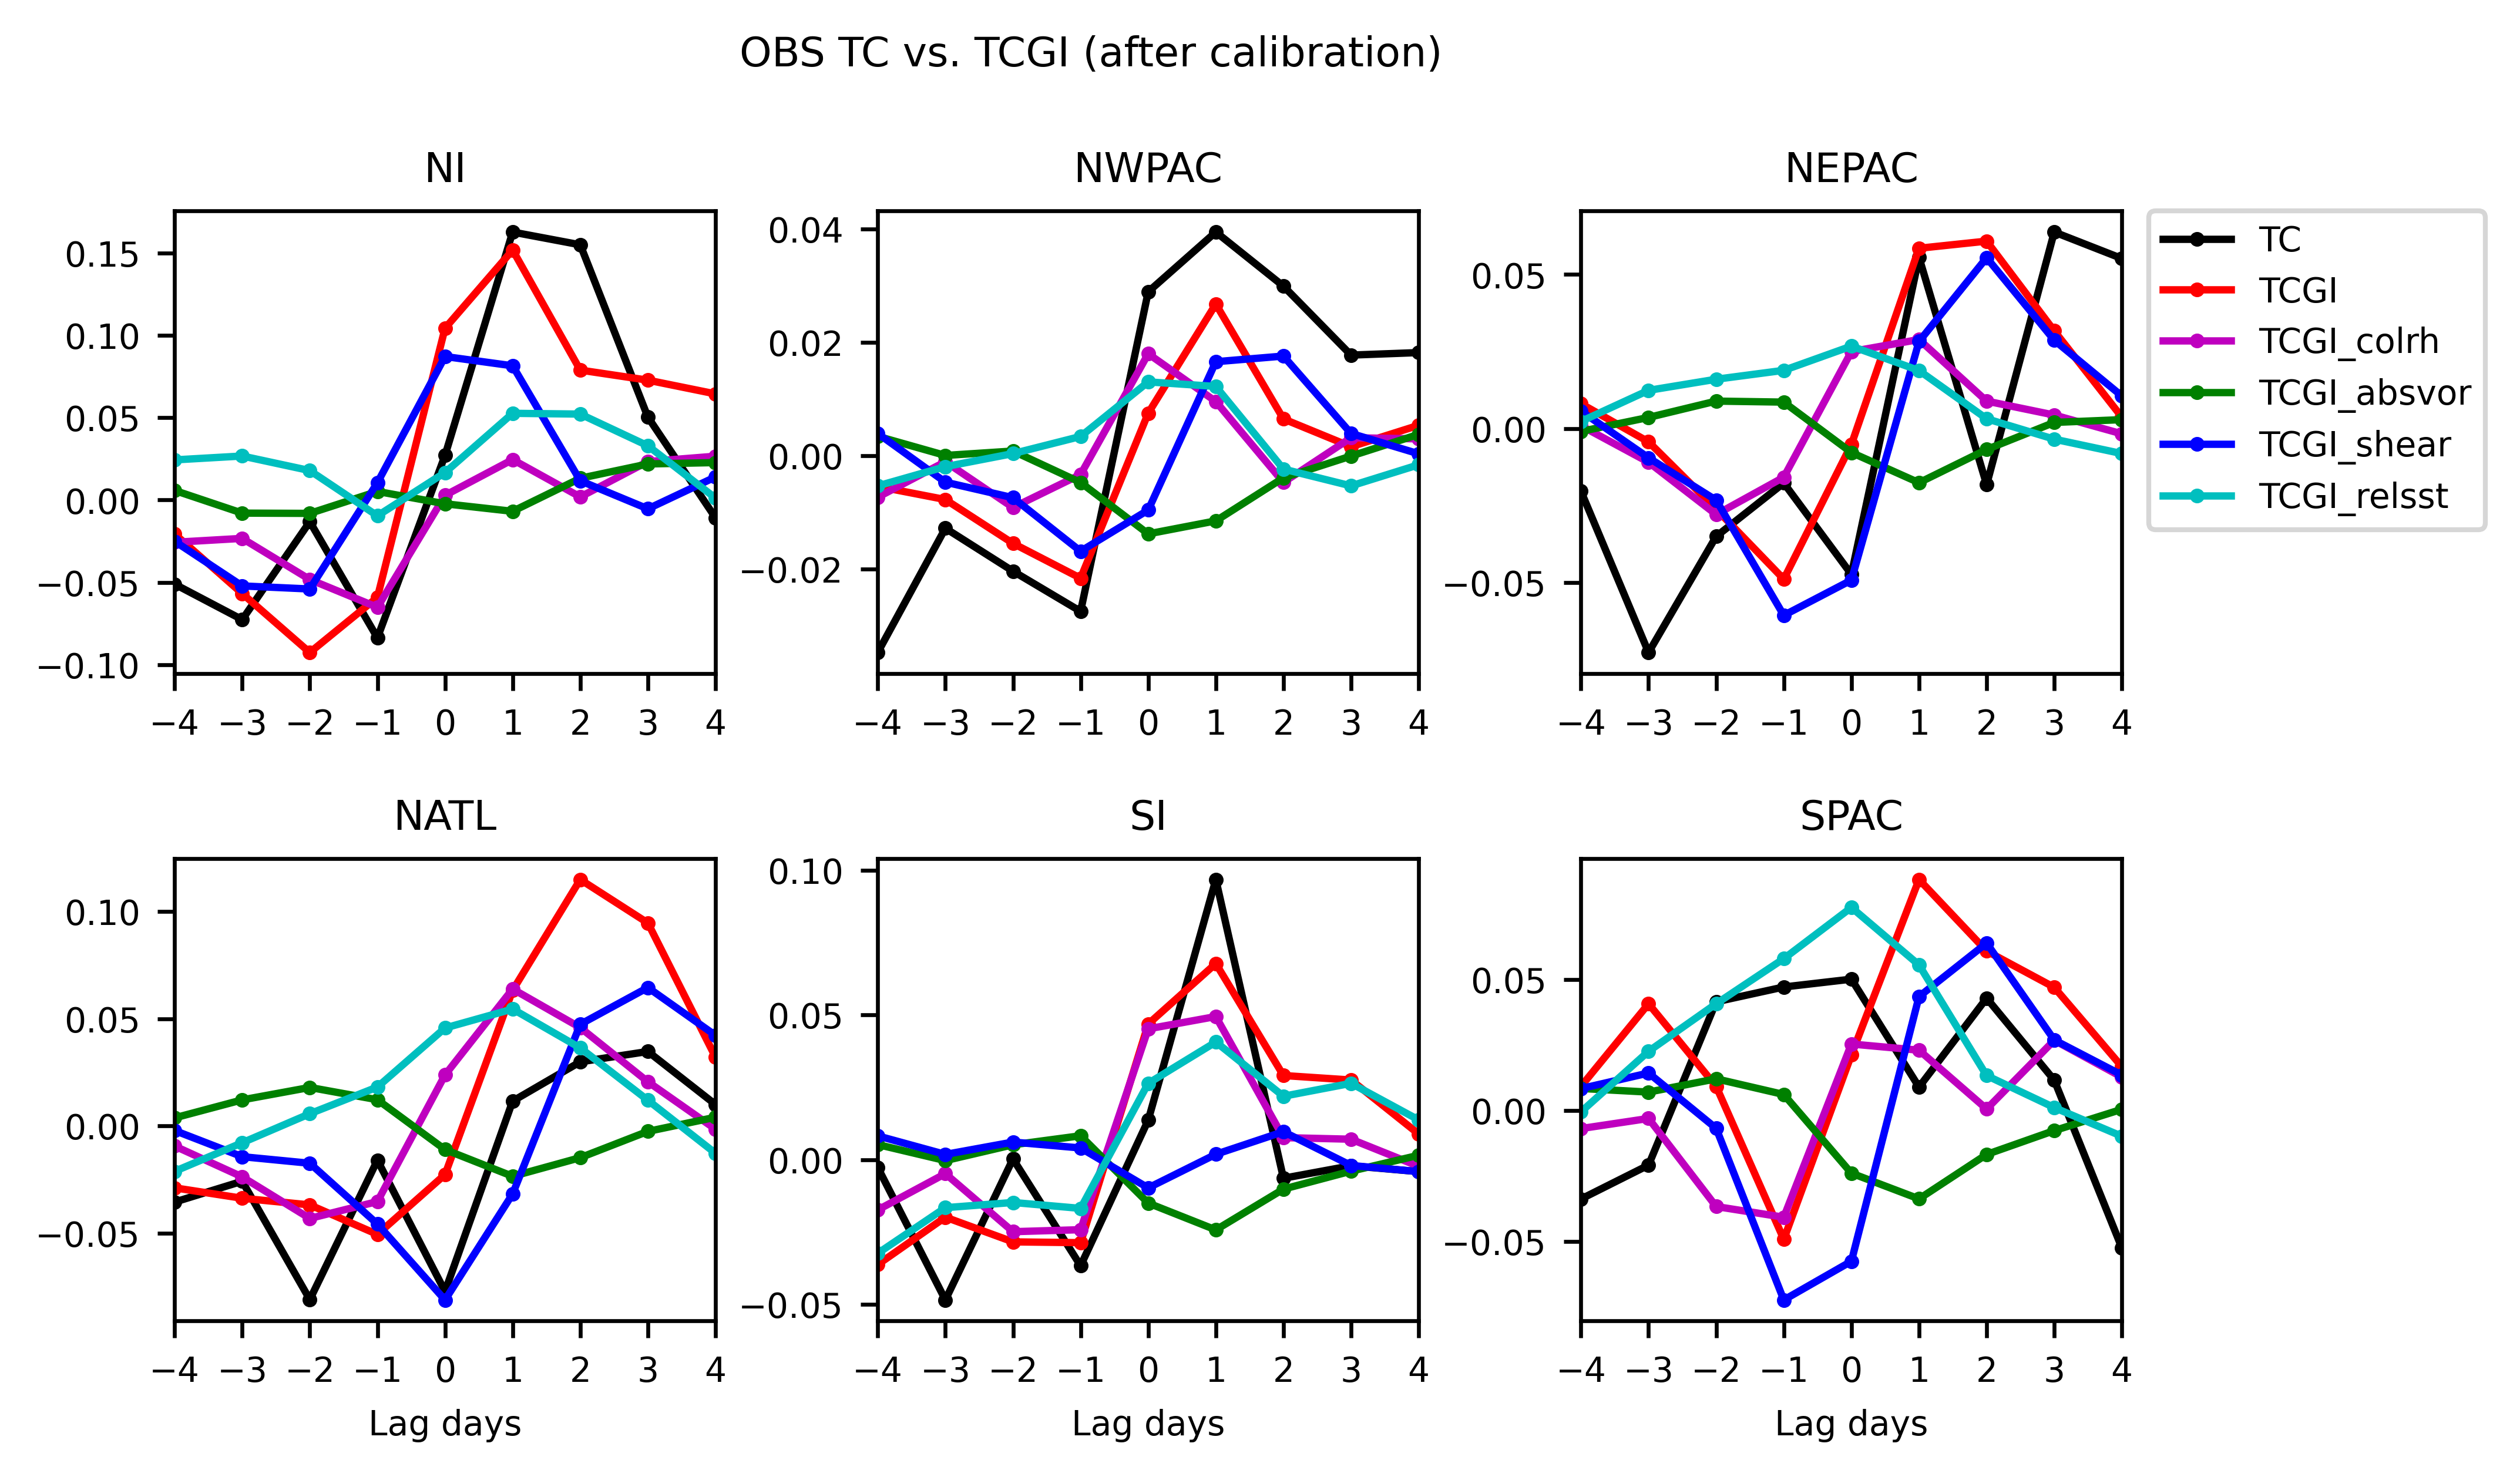

In [25]:
for iplt in range(0, 2):
    c_obs = np.array([5,1,1,3,3,3])
    fig, axes = plt.subplots(2,3,figsize=(6.5, 5),dpi=600)
    font = 7
    plt.rcParams.update({'font.size': font})
    plt.subplots_adjust(left=0.1,right=0.95,top=0.88,bottom=0.25, wspace=0.3, hspace=0.4)
    for ibasin in range(0, nbasin):
        plt.subplot(2, 3, ibasin+1)
        plt.plot(bin_center, TC_obs_ano[:, ibasin], 'k-o', markersize=2)
        plt.plot(bin_center, TCGI_obs_ano[:,ibasin]*c_obs[ibasin], 'r-o', markersize=2)
        plt.plot(bin_center, TCGI_colrh_obs_ano[:,ibasin]*c_obs[ibasin], 'm-o', markersize=2)
        plt.plot(bin_center, TCGI_absvor_obs_ano[:,ibasin]*c_obs[ibasin], 'g-o', markersize=2)
        plt.plot(bin_center, TCGI_shear_obs_ano[:,ibasin]*c_obs[ibasin], 'b-o', markersize=2)
        plt.plot(bin_center, TCGI_relsst_obs_ano[:,ibasin]*c_obs[ibasin], 'c-o', markersize=2)
        
        plt.title(basin_list[ibasin])
        if ibasin == 2:
            plt.legend(['TC','TCGI','TCGI_colrh','TCGI_absvor','TCGI_shear','TCGI_relsst'], bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

        if ibasin > 2:
            plt.xlabel('Lag days')

        if iplt == 1:
            plt.xlim([-4,4])
            plt.xticks(np.arange(-4, 5))
    plt.suptitle('OBS TC vs. TCGI (after calibration)')
    plt.show()

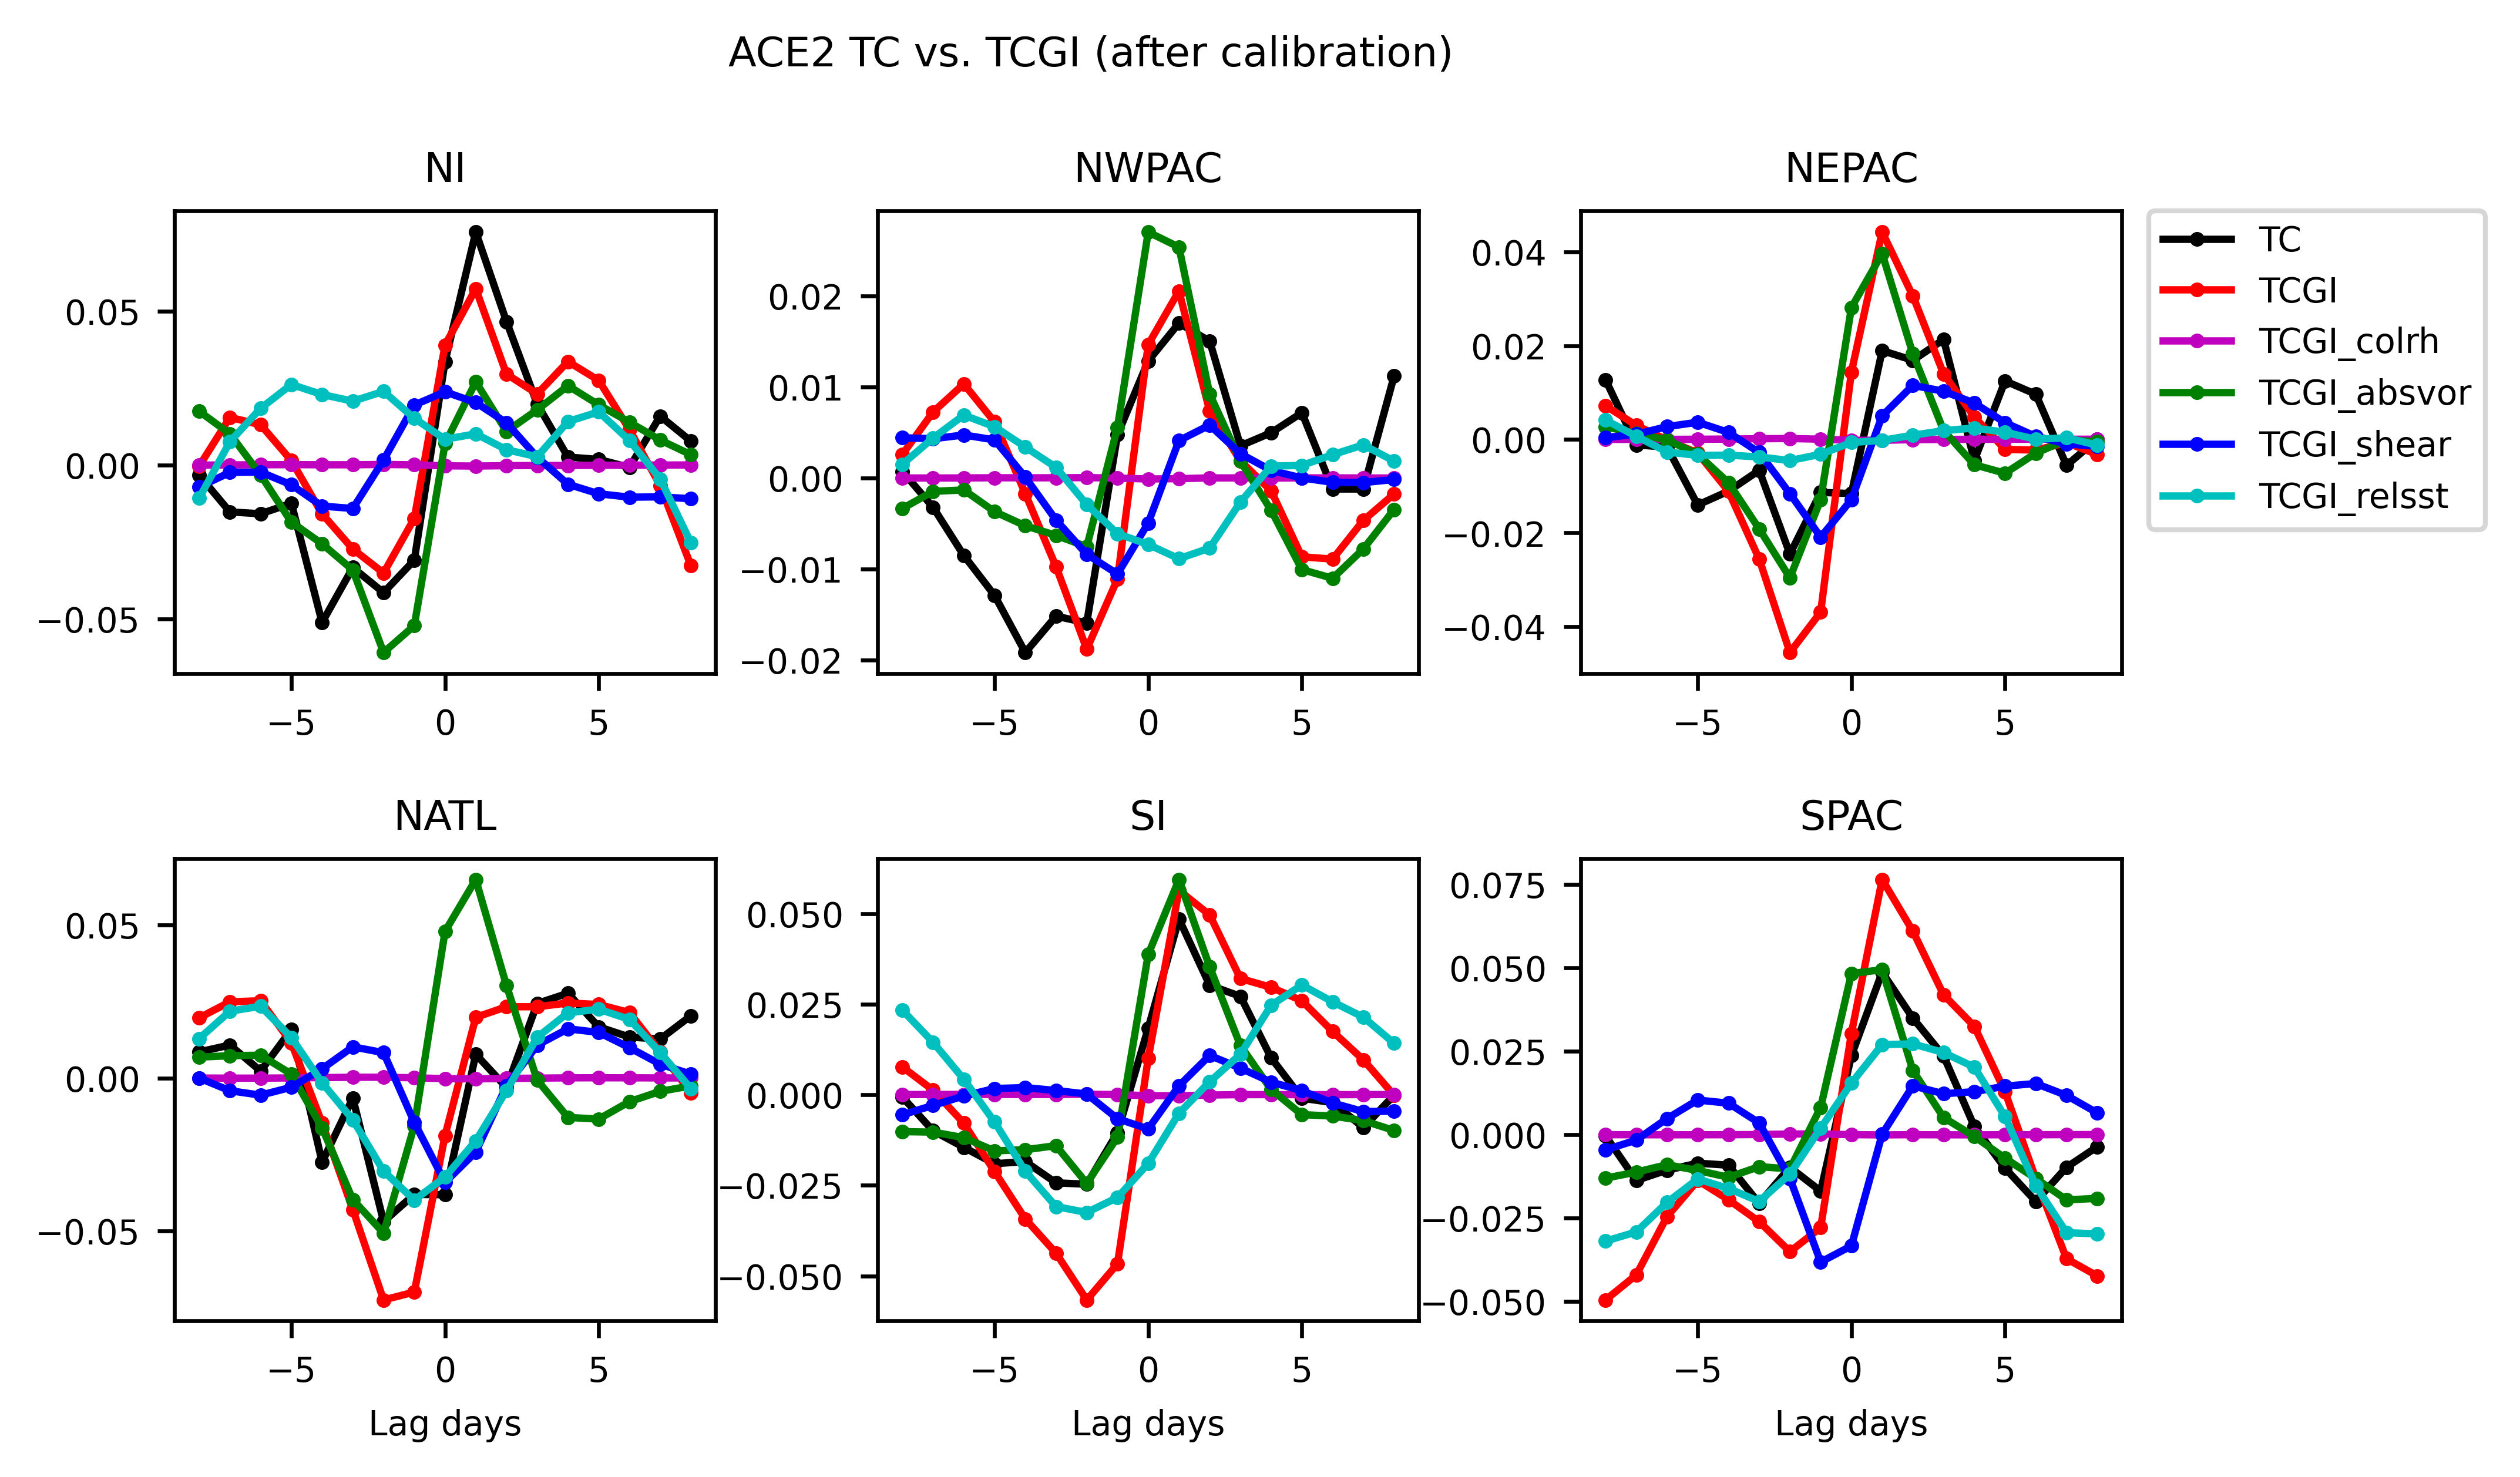

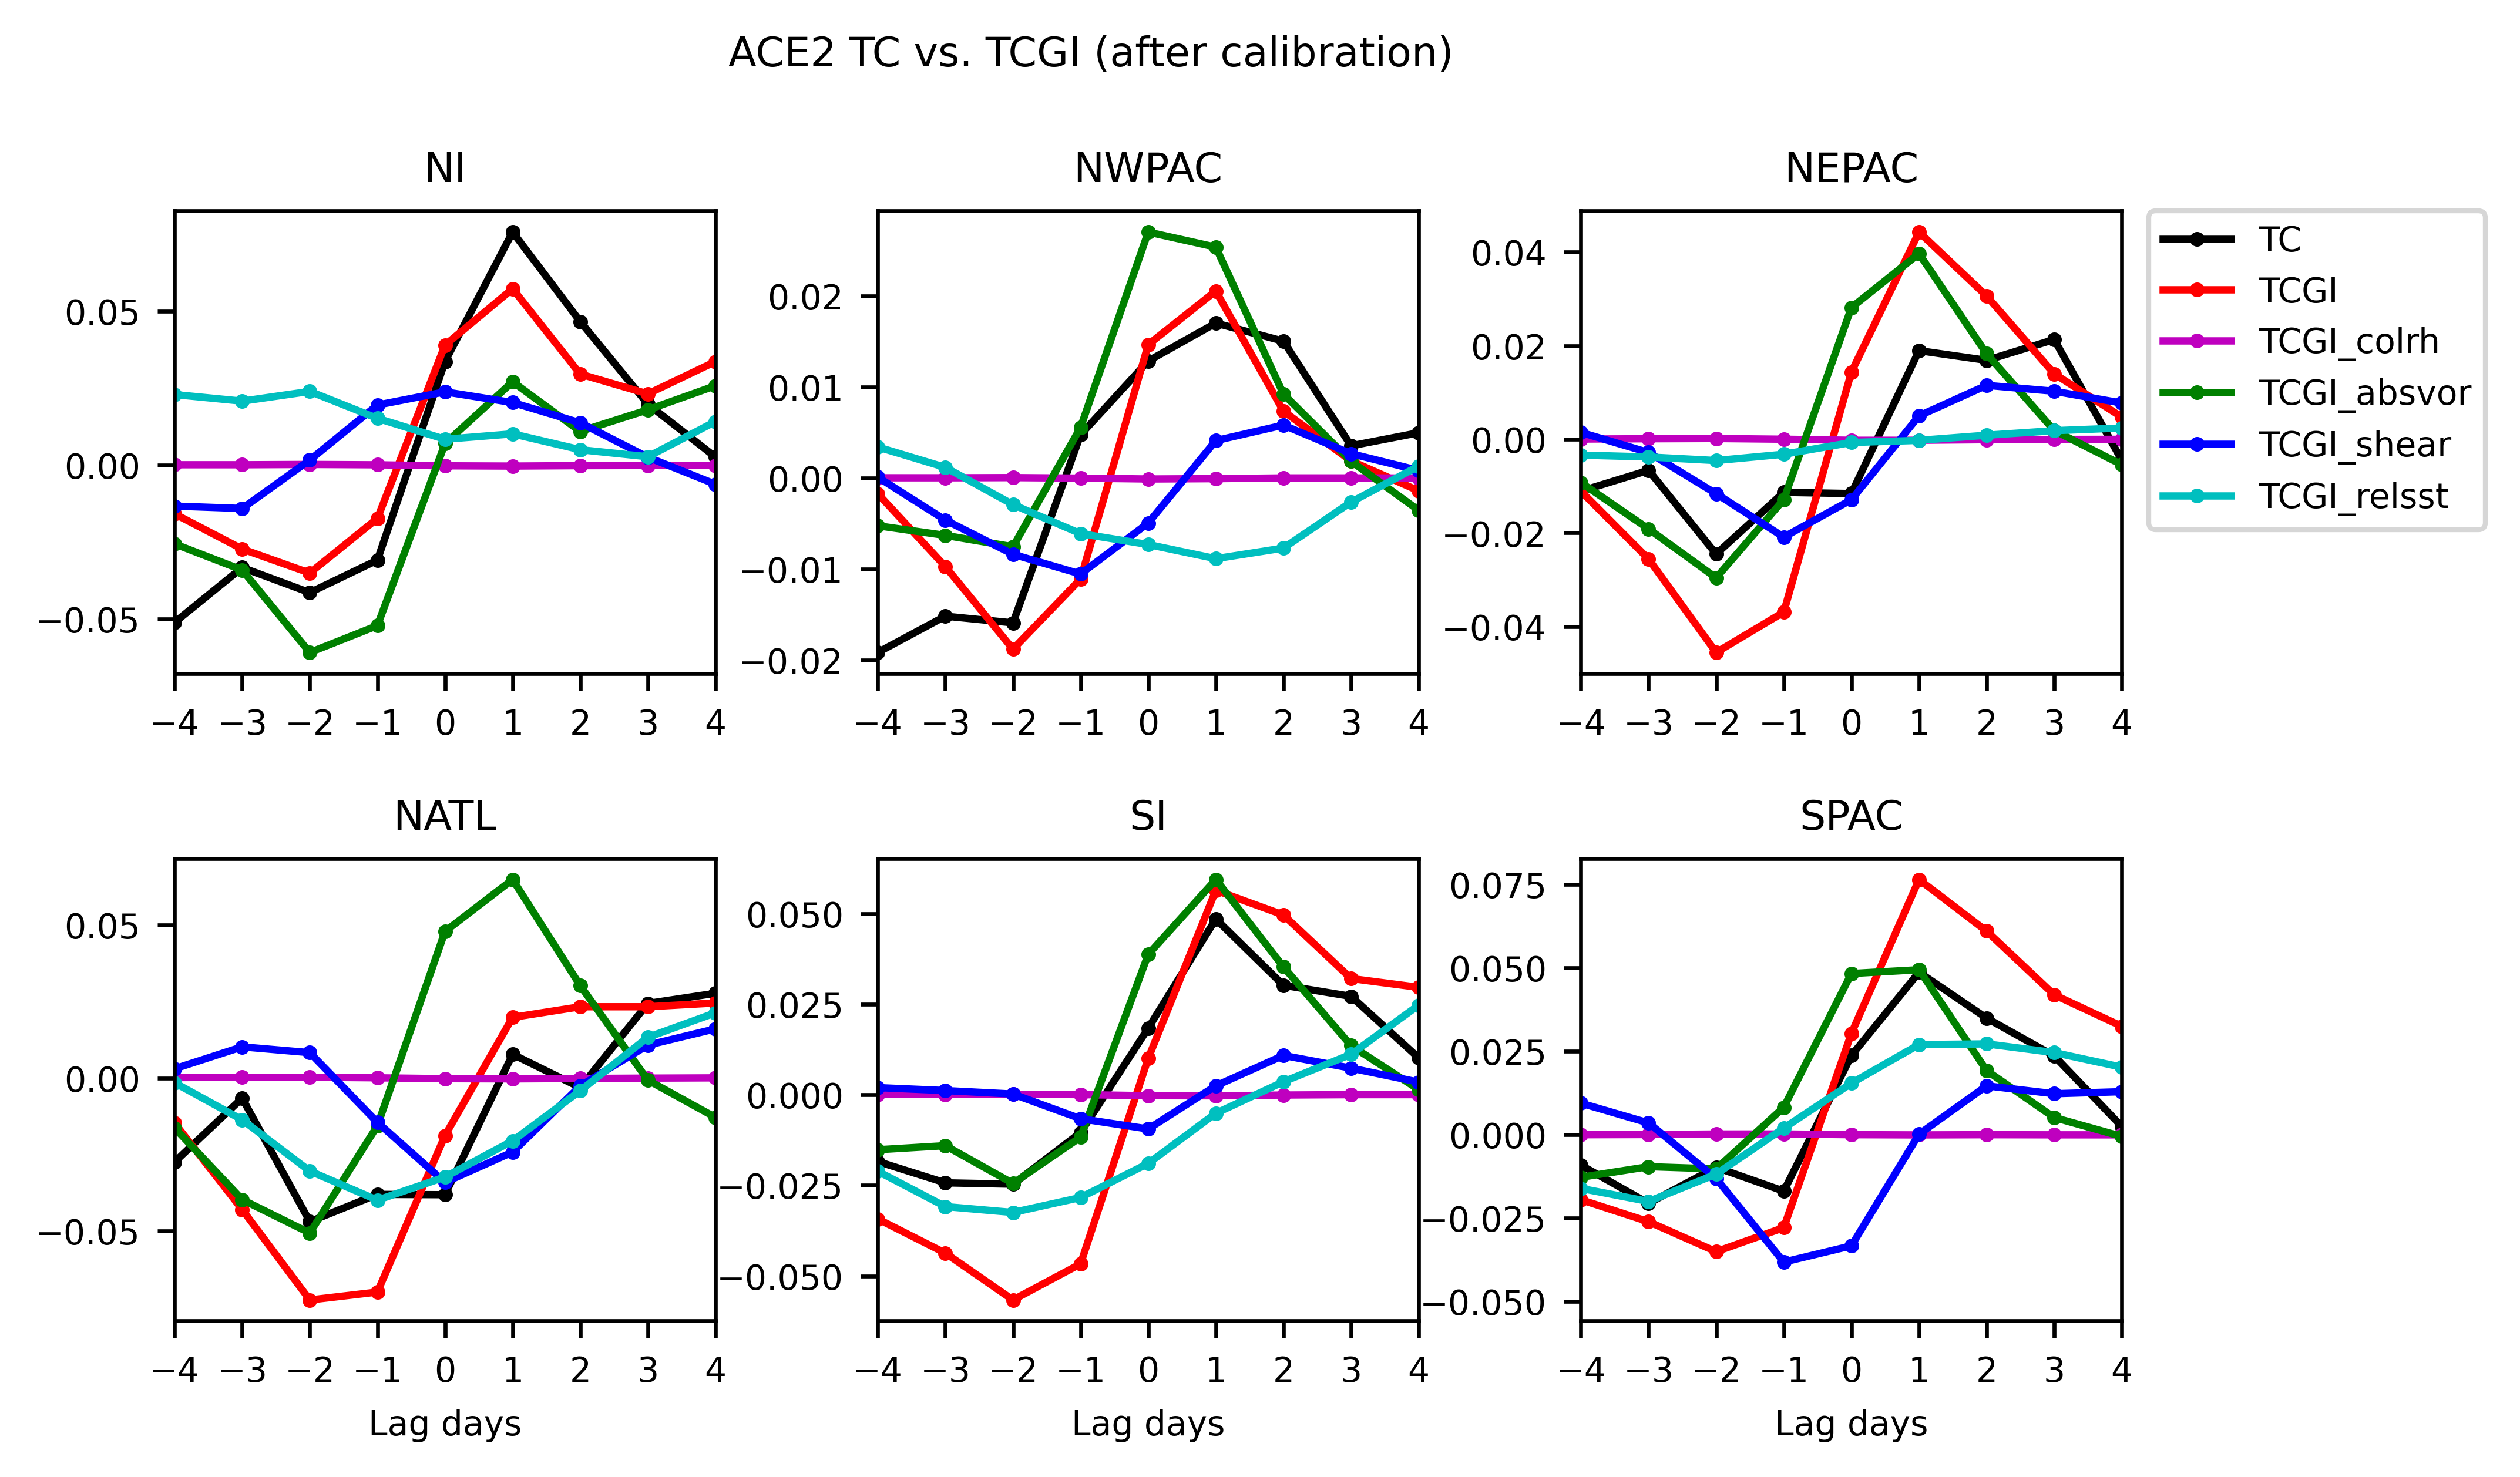

In [27]:
for iplt in range(0, 2):
    c_obs = np.array([5,1,1,3,3,3])
    fig, axes = plt.subplots(2,3,figsize=(6.5, 5),dpi=600)
    font = 7
    plt.rcParams.update({'font.size': font})
    plt.subplots_adjust(left=0.1,right=0.95,top=0.88,bottom=0.25, wspace=0.3, hspace=0.4)
    for ibasin in range(0, nbasin):
        plt.subplot(2, 3, ibasin+1)
        plt.plot(bin_center, TC_ace2_ano[:, ibasin], 'k-o', markersize=2)
        plt.plot(bin_center, TCGI_ace2_ano[:,ibasin]*c_obs[ibasin], 'r-o', markersize=2)
        plt.plot(bin_center, TCGI_colrh_ace2_ano[:,ibasin]*c_obs[ibasin], 'm-o', markersize=2)
        plt.plot(bin_center, TCGI_absvor_ace2_ano[:,ibasin]*c_obs[ibasin], 'g-o', markersize=2)
        plt.plot(bin_center, TCGI_shear_ace2_ano[:,ibasin]*c_obs[ibasin], 'b-o', markersize=2)
        plt.plot(bin_center, TCGI_relsst_ace2_ano[:,ibasin]*c_obs[ibasin], 'c-o', markersize=2)
        
        plt.title(basin_list[ibasin])
        if ibasin == 2:
            plt.legend(['TC','TCGI','TCGI_colrh','TCGI_absvor','TCGI_shear','TCGI_relsst'], bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

        if ibasin > 2:
            plt.xlabel('Lag days')

        if iplt == 1:
            plt.xlim([-4,4])
            plt.xticks(np.arange(-4, 5))
    plt.suptitle('ACE2 TC vs. TCGI (after calibration)')
    plt.show()